This script explores patterns in the data

In [73]:
import pandas as pd

# Load the CSV
df = pd.read_csv("../data/processed/csv_output/Jobs.csv")

In [74]:
df.head()

,UUID,JobID,ArrayID,JobName,IsArray,Interactive,Preempted,Account,User,Constraints,...,Nodes,NodeList,CPUs,Memory,GPUs,GPUType,GPUMemUsage,GPUComputeUsage,CPUMemUsage,CPUComputeUsage
0,'28500523017388652451738865260',28500523,NaN,5140_nr,False,NaN,False,pi_mraessi_umassd_edu,kgupta3_umassd_edu,"['\'amd1900x\'', '\'amd7402\'', '\'amd7502\'',...",...,umd-cscdr-cpu[003-010],"[umd-cscdr-cpu003, umd-cscdr-cpu004, umd-cscdr...",441,661500,NaN,NaN,0.0,0.0,1.006585e+11,14.494155
1,'28519169017389527551738952757',28519169,NaN,250pppfnvt,False,NaN,False,pi_mmayes_umassd_edu,mjamal_umassd_edu,"['\'avx512\'', '\'amd1900x\'', '\'amd7402\'', ...",...,umd-cscdr-cpu[022-023],"[umd-cscdr-cpu022, umd-cscdr-cpu023]",128,131072,NaN,NaN,0.0,0.0,7.296860e+08,0.781196
2,'28600142017393197271739334335',28600142,NaN,spectral_lines,False,NaN,False,pi_nsk_umass_edu,lyang_umass_edu,"['\'amd1900x\'', '\'amd7402\'', '\'amd7502\'',...",...,"cpu[069,073,076-078]","[cpu069, cpu073, cpu076, cpu077, cpu078]",10,2560000,NaN,NaN,0.0,0.0,3.263569e+11,8.240410
3,'28958081017395470261739998627',28958081,NaN,quarterly-updates,False,NaN,False,root,root,NaN,...,cpu073,[cpu073],192,196608,NaN,NaN,0.0,0.0,5.284716e+09,0.390863
4,'28958084017395470261739998627',28958084,NaN,quarterly-updates,False,NaN,False,root,root,NaN,...,cpu076,[cpu076],192,196608,NaN,NaN,0.0,0.0,5.386953e+09,0.439131


### Questions and findings in data

1. ArrayID: This is probably not a good feature for this work. It has some missing values(Perhaps those jobs are not arrayjobs). 
2. UUID: not so sure how relevant this is
3. JobID: This is important for outreach. One can list some jobs a user underutilised GPU
4. JobName: Not relevant- We can use JobID. 
5. Isarray: This is a good variable to get to sense of whether array jobs underutilise GPU compared to non-array jobs( 1 for array and 0 for non-array)
6. Interactive: This is also a very good feature to determine if interactive jobs are more prone to GPU underutilization. (maybe 1 for interactive and 0 otherwise.: Replace all missing values with 0 and anything else 1)
7. Preempted: Need more information on this.
8. Account: for modeling, we can group account into three( top 10, middle 10, lower). There is also "root" account, what does that mean. This is similar in users? Does that mean no pi_group?
9. User: This has similar issues as the accounts(maybe useful for listing users underutilizing GPU)
10. Constraints: Need more info on that( Maybe restrictions on resources to be used? or available?) If so we could categorise jobs as having constraint or not( 0 or 1)
11. QOS: Need more information on it. Maybe normal==1 otherwise 0.
12. Status: This is a useful feature. We can investigate if failed jobs are the once underutilizing GPUs, if so the problem is more on helping people to avoid failed jobs. Otherwise, take further actions. (failed, cancelled, out-of-memory and completed, Timeout)
13. Exitcode: Need more on this to  validate its importance. 
14. SubmitTime, StartTime and EndTime are relevant for time trends( analysing, waittimes, and the time the job spend running)
15. Elapsed and TimeLimit( These are also good features: Will think through well)
16. Partition: This is very important feature. Maybe we should reduce levels into two or three(building? )
17. Nodes and Nodelist? not sure if they are important. 
18. 

In [7]:


# Filter for jobs that requested GPUs
gpu_jobs = df[df['GPUs'] > 0]

# Group by Account (PI group)
pi_group_counts = gpu_jobs['Account'].value_counts()
print("Top PI groups requesting GPUs:")
print(pi_group_counts.head(10))

# Group by GPUType
gpu_type_counts = gpu_jobs['GPUType'].value_counts()
print("\nMost requested GPU types:")
print(gpu_type_counts.head(10))

# Group by User
user_counts = gpu_jobs['User'].value_counts()
print("\nTop users requesting GPUs:")
print(user_counts.head(10))

# Optionally, group by Partition
partition_counts = gpu_jobs['Partition'].value_counts()
print("\nPartitions used for GPU jobs:")
print(partition_counts)

Top PI groups requesting GPUs:
Account
pi_pchien_umass_edu         4458
pi_jdomke_umass_edu         2051
pi_bioch642_umass_edu        961
pi_bo_sheng_umb_edu          507
pi_miyyer_umass_edu          396
pi_ahoumansadr_umass_edu     263
pi_jianhanc_umass_edu        177
pi_smaji_umass_edu           174
pi_sunghoonlee_umass_edu     150
pi_zhuzhang_uri_edu          146
Name: count, dtype: int64

Most requested GPU types:
GPUType
[l40s]        3573
[1080_ti]     2205
[a100]        1372
[titan_x]     1109
[a40]          870
[2080_ti]      799
[m40]          728
[v100]         617
[h100]          59
[rtx_8000]      52
Name: count, dtype: int64

Top users requesting GPUs:
User
pchien_umass_edu         4458
joohwanko_umass_edu      2051
emccleary_umass_edu       961
allen_yang001_umb_edu     507
yekyungkim_umass_edu      280
jroh_umass_edu            216
shanlongli_umass_edu      177
limr_iastate_edu          146
tlanghorst_umass_edu      144
rdaroya_umass_edu         113
Name: count, dtype: i

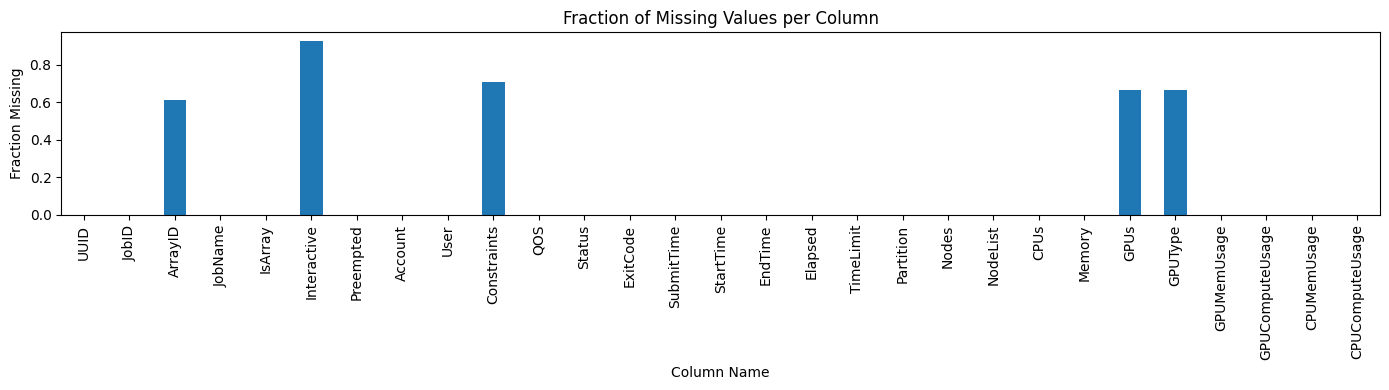

In [8]:
import matplotlib.pyplot as plt

df.isnull().mean().plot(kind='bar', figsize=(14, 4), title='Fraction of Missing Values per Column')
plt.ylabel('Fraction Missing')
plt.xlabel('Column Name')
plt.tight_layout()
plt.show()

## Why the Missing values?
We see that, there are missing values in features su

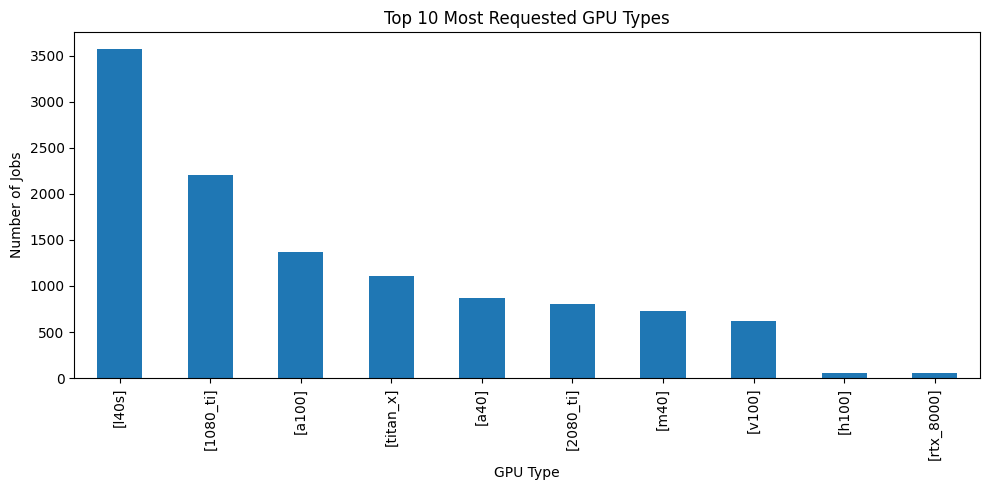

In [9]:
# Visualize the top 10 most requested GPU types
gpu_type_counts.head(10).plot(kind='bar', figsize=(10, 5), title='Top 10 Most Requested GPU Types')
plt.ylabel('Number of Jobs')
plt.xlabel('GPU Type')
plt.tight_layout()
plt.show()


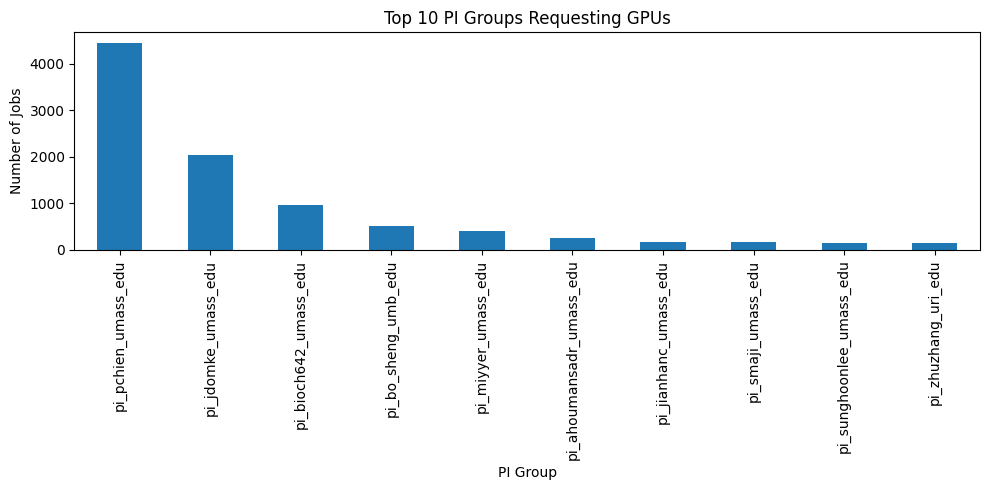

In [10]:

# Visualize the top 10 PI groups requesting GPUs
pi_group_counts.head(10).plot(kind='bar', figsize=(10, 5), title='Top 10 PI Groups Requesting GPUs')
plt.ylabel('Number of Jobs')
plt.xlabel('PI Group')
plt.tight_layout()
plt.show()


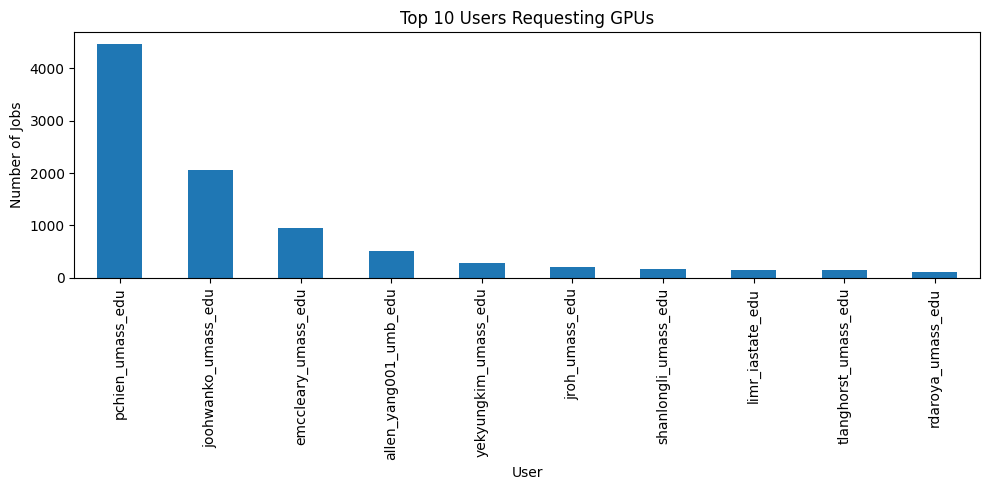

In [7]:

# Visualize the top 10 users requesting GPUs
user_counts.head(10).plot(kind='bar', figsize=(10, 5), title='Top 10 Users Requesting GPUs')
plt.ylabel('Number of Jobs')
plt.xlabel('User')
plt.tight_layout()
plt.show()


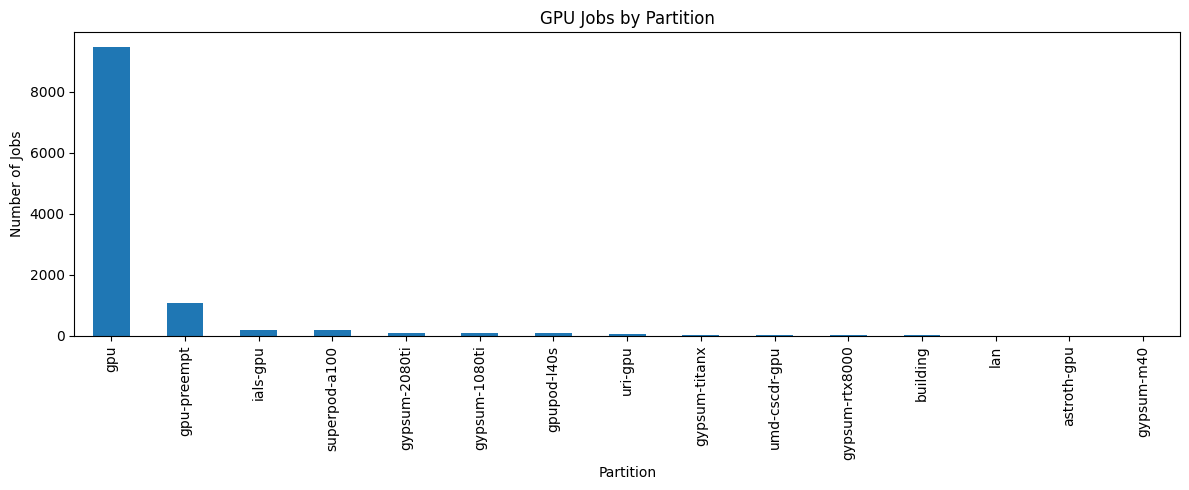

In [11]:

# Visualize the distribution of GPU jobs across partitions
partition_counts.plot(kind='bar', figsize=(12, 5), title='GPU Jobs by Partition')
plt.ylabel('Number of Jobs')
plt.xlabel('Partition')
plt.tight_layout()
plt.show()

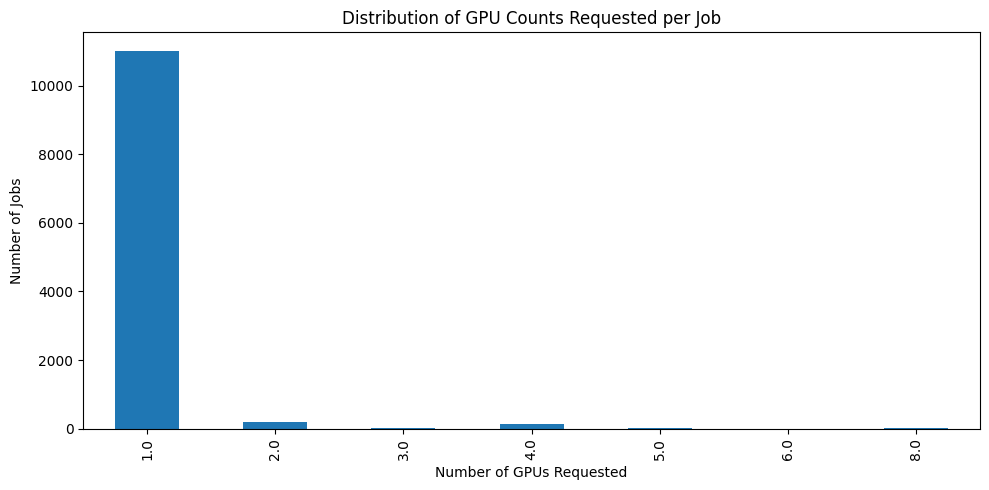

In [9]:
# Visualize the distribution of GPU counts requested per job
gpu_jobs['GPUs'].value_counts().sort_index().plot(kind='bar', figsize=(10, 5), title='Distribution of GPU Counts Requested per Job')
plt.ylabel('Number of Jobs')
plt.xlabel('Number of GPUs Requested')
plt.tight_layout()
plt.show()

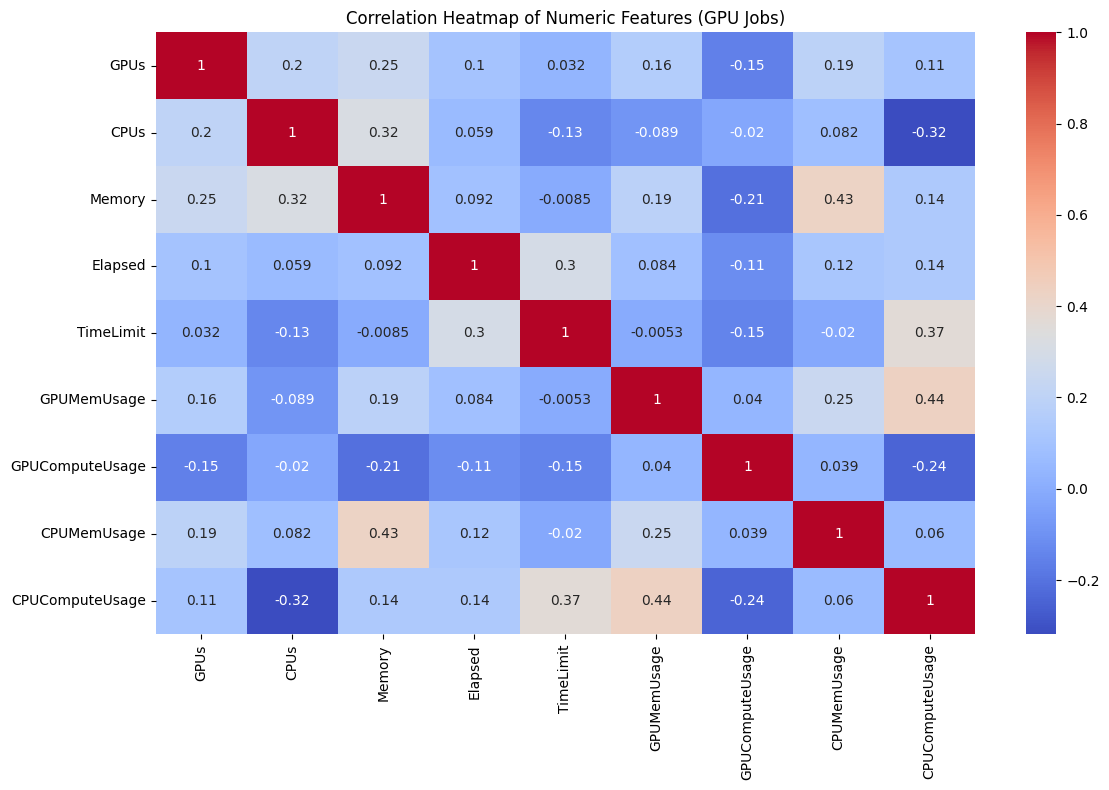

In [13]:
import seaborn as sns

# 1. Heatmap: Correlation between numeric features for GPU jobs
plt.figure(figsize=(12, 8))
sns.heatmap(gpu_jobs[['GPUs', 'CPUs', 'Memory', 'Elapsed', 'TimeLimit', 'GPUMemUsage', 'GPUComputeUsage', 'CPUMemUsage', 'CPUComputeUsage']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Numeric Features (GPU Jobs)')
plt.tight_layout()
plt.show()


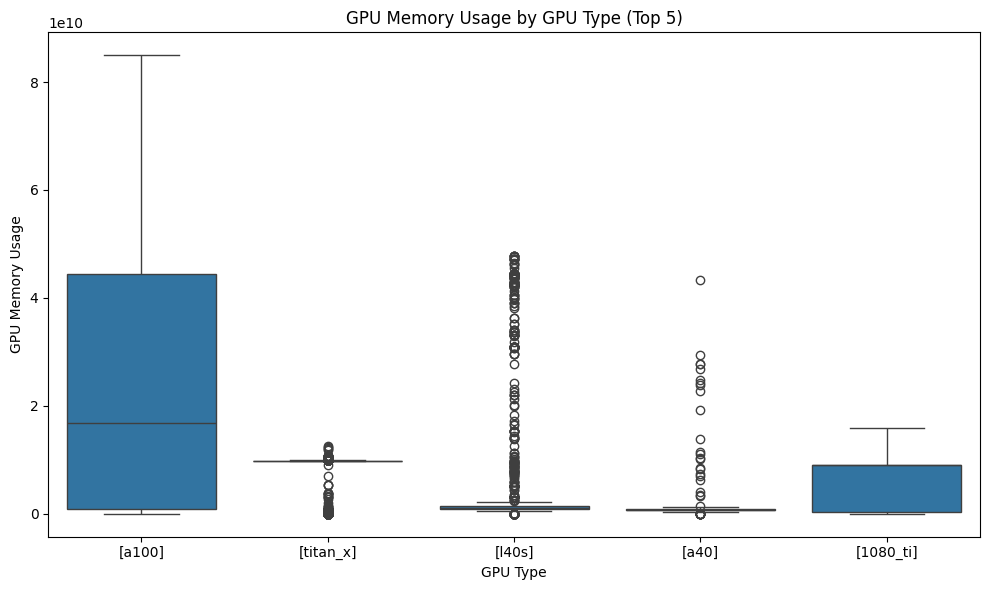

In [14]:

# 2. Boxplot: GPU Memory Usage by GPU Type (top 5 types)
top_gpu_types = gpu_jobs['GPUType'].value_counts().head(5).index
plt.figure(figsize=(10, 6))
sns.boxplot(data=gpu_jobs[gpu_jobs['GPUType'].isin(top_gpu_types)], x='GPUType', y='GPUMemUsage')
plt.title('GPU Memory Usage by GPU Type (Top 5)')
plt.ylabel('GPU Memory Usage')
plt.xlabel('GPU Type')
plt.tight_layout()
plt.show()


/var/folders/wn/4sm351b900qg_5z1gvp_51vw0000gn/T/ipykernel_10095/3146824118.py:4: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(data=gpu_jobs[gpu_jobs['Partition'].isin(top_partitions)], x='Partition', y='Elapsed', scale='width', inner='quartile')


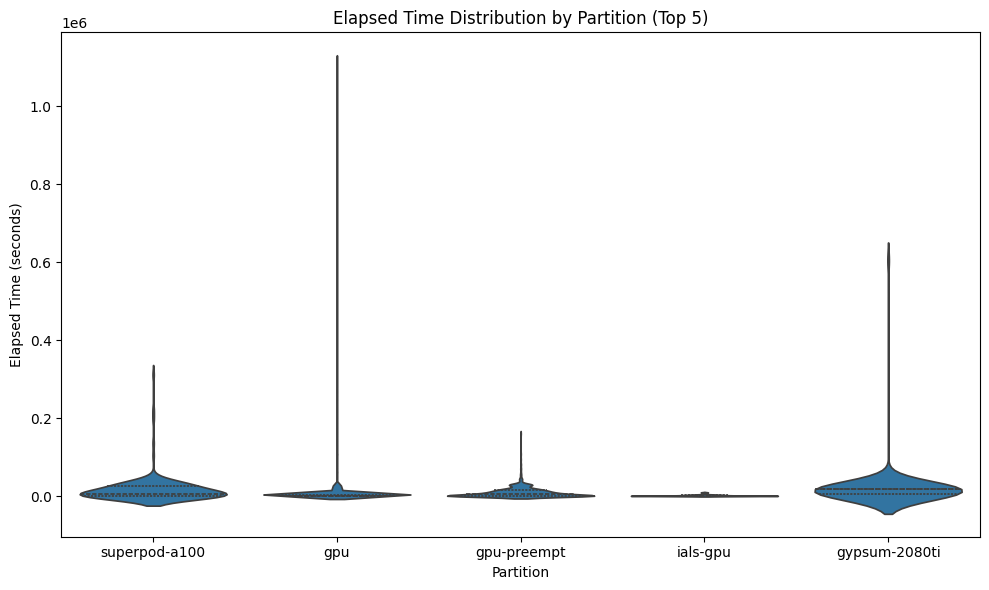

In [15]:

# 3. Violin plot: Elapsed time distribution by Partition (top 5 partitions)
top_partitions = gpu_jobs['Partition'].value_counts().head(5).index
plt.figure(figsize=(10, 6))
sns.violinplot(data=gpu_jobs[gpu_jobs['Partition'].isin(top_partitions)], x='Partition', y='Elapsed', scale='width', inner='quartile')
plt.title('Elapsed Time Distribution by Partition (Top 5)')
plt.ylabel('Elapsed Time (seconds)')
plt.xlabel('Partition')
plt.tight_layout()
plt.show()


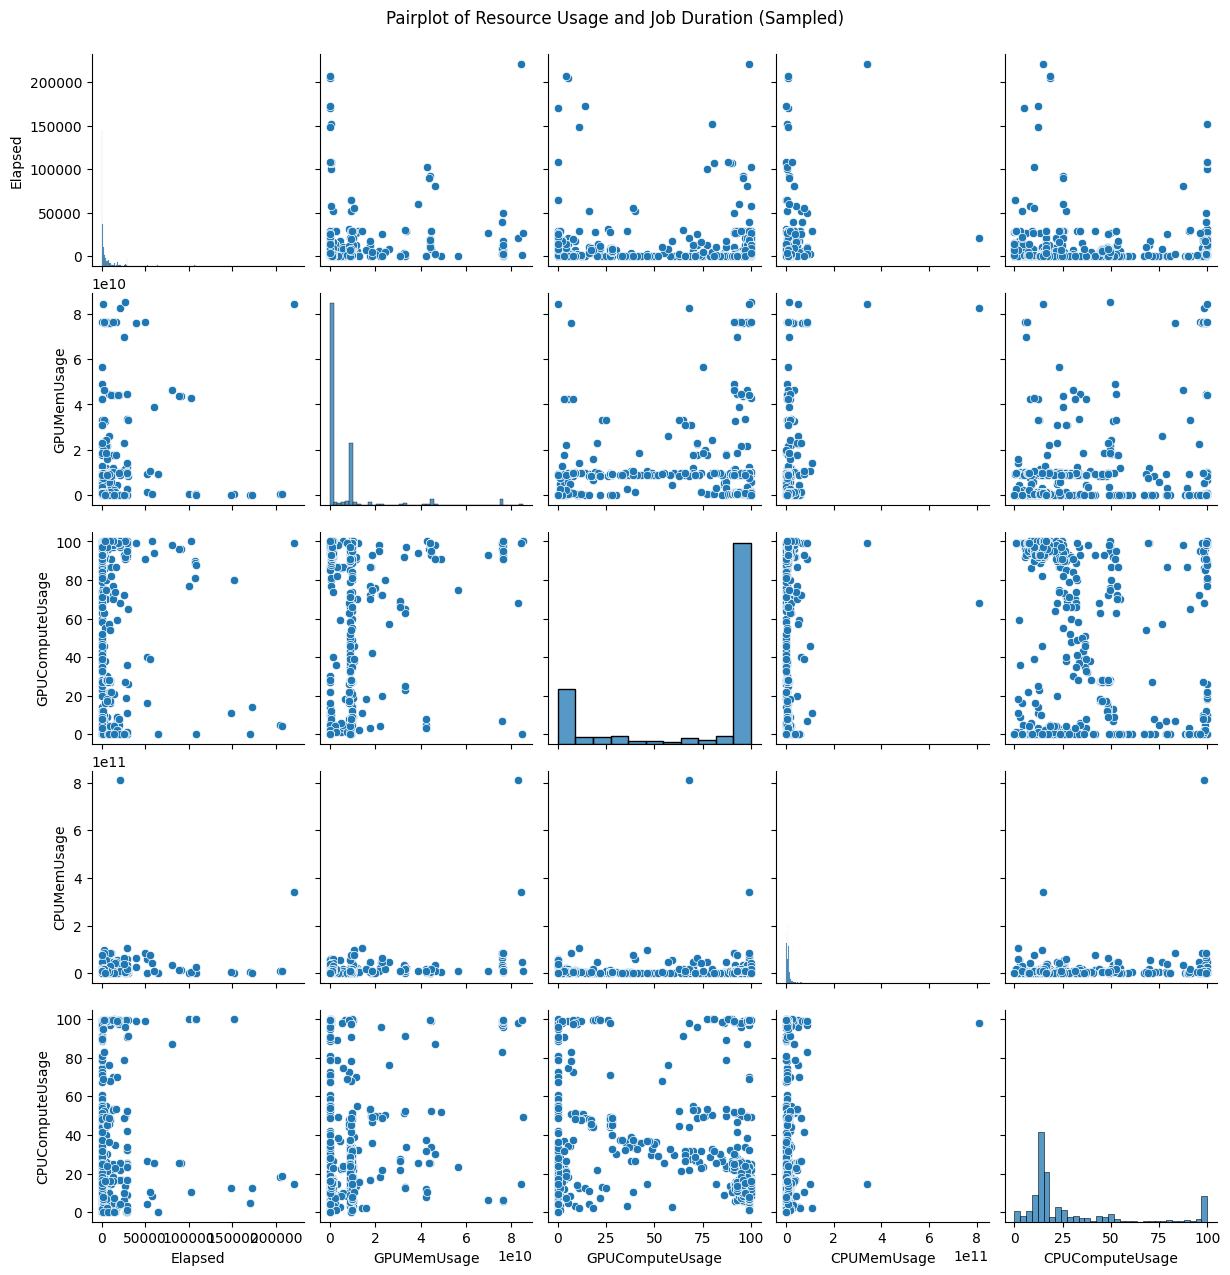

In [16]:

# 4. Pairplot: Relationship between resource usage and job duration (sample for speed)
sampled = gpu_jobs.sample(n=1000, random_state=42) if len(gpu_jobs) > 1000 else gpu_jobs
sns.pairplot(sampled, vars=['Elapsed', 'GPUMemUsage', 'GPUComputeUsage', 'CPUMemUsage', 'CPUComputeUsage'])
plt.suptitle('Pairplot of Resource Usage and Job Duration (Sampled)', y=1.02)
plt.show()

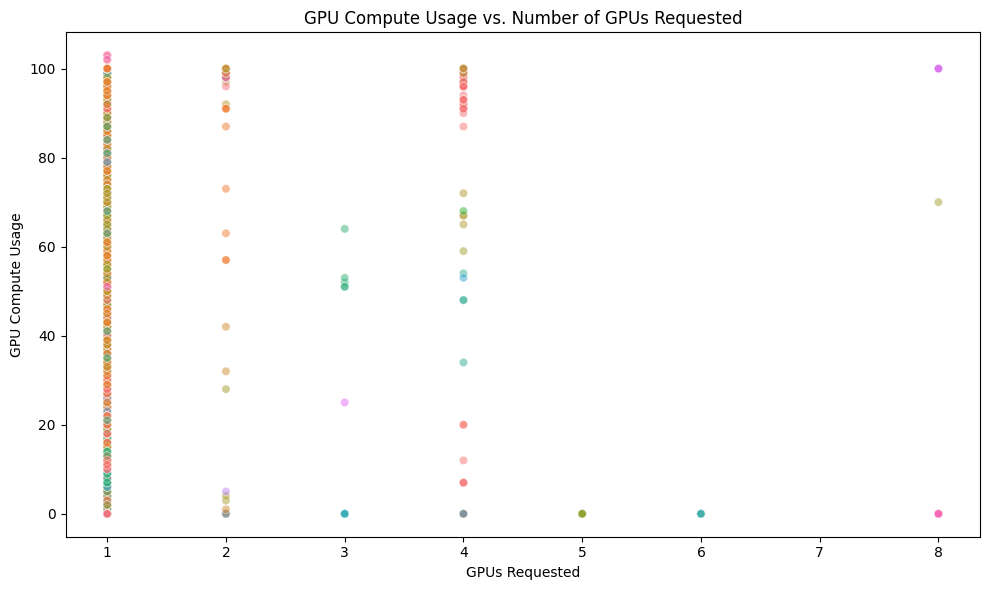

In [17]:
# Visualizations to help flag users who requested GPUs but are underutilizing

# 1. Scatter plot: GPUComputeUsage vs. GPUs requested (per user)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=gpu_jobs, x='GPUs', y='GPUComputeUsage', hue='User', legend=False, alpha=0.5)
plt.title('GPU Compute Usage vs. Number of GPUs Requested')
plt.xlabel('GPUs Requested')
plt.ylabel('GPU Compute Usage')
plt.tight_layout()
plt.show()


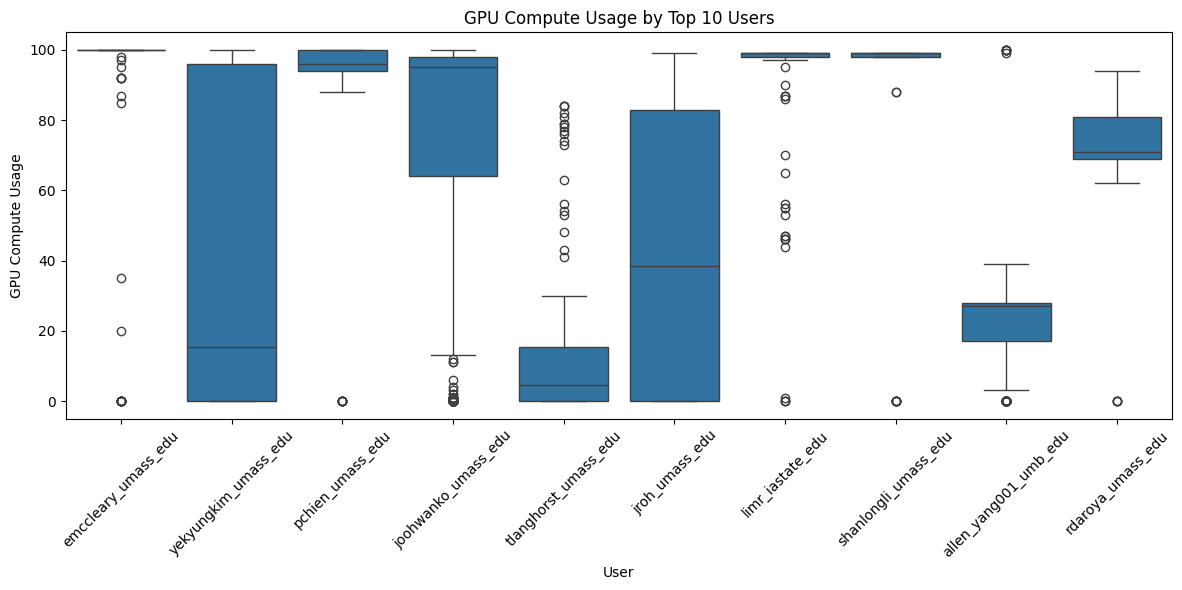

In [18]:

# 2. Boxplot: GPUComputeUsage by User (top 10 users)
top10_users = user_counts.head(10).index
plt.figure(figsize=(12, 6))
sns.boxplot(data=gpu_jobs[gpu_jobs['User'].isin(top10_users)], x='User', y='GPUComputeUsage')
plt.title('GPU Compute Usage by Top 10 Users')
plt.ylabel('GPU Compute Usage')
plt.xlabel('User')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


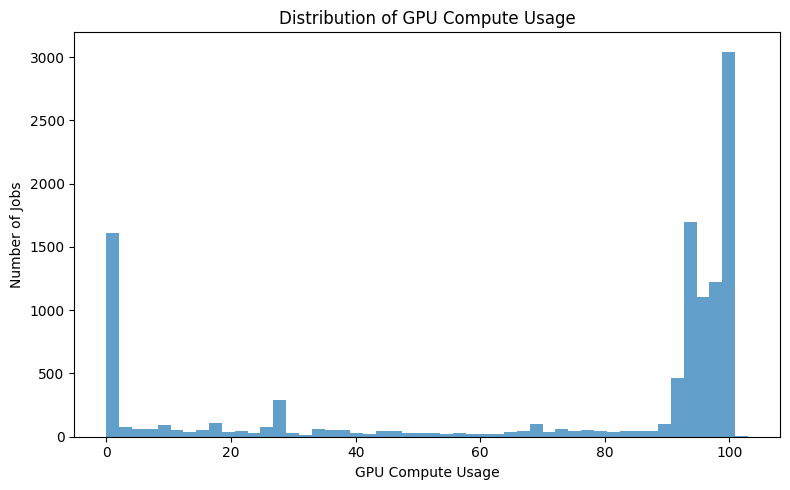

In [16]:

# 3. Histogram: Distribution of GPUComputeUsage (all jobs)
plt.figure(figsize=(8, 5))
gpu_jobs['GPUComputeUsage'].plot(kind='hist', bins=50, alpha=0.7)
plt.title('Distribution of GPU Compute Usage')
plt.xlabel('GPU Compute Usage')
plt.ylabel('Number of Jobs')
plt.tight_layout()
plt.show()


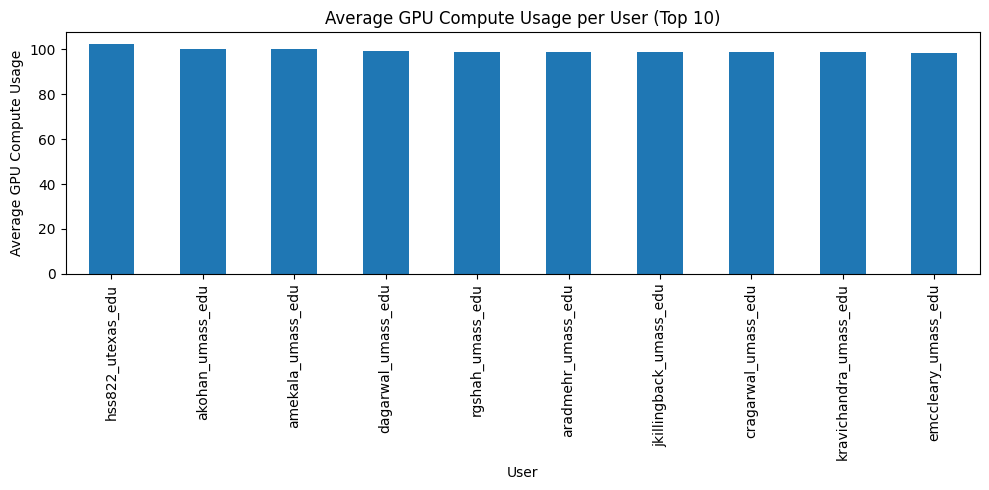

In [20]:

# 4. Bar plot: Average GPUComputeUsage per user (top 10 users)
avg_gpu_util = gpu_jobs.groupby('User')['GPUComputeUsage'].mean().sort_values(ascending=False).head(10)
avg_gpu_util.plot(kind='bar', figsize=(10, 5), title='Average GPU Compute Usage per User (Top 10)')
plt.ylabel('Average GPU Compute Usage')
plt.xlabel('User')
plt.tight_layout()
plt.show()

## preprocessing Data for clustering

In [21]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# Prepare the data for clustering: use average GPU compute usage per user
user_gpu_util = avg_gpu_util.values.reshape(-1, 1)

# Scale the data between 0 and 1
scaler = MinMaxScaler()
user_gpu_util_scaled = scaler.fit_transform(user_gpu_util)

# Define thresholds for underutilize, moderate, and full usage
# (e.g., <0.33: underutilize, 0.33-0.66: moderate, >0.66: full usage)
usage_labels = np.where(user_gpu_util_scaled < 0.33, 'Underutilize',
                np.where(user_gpu_util_scaled < 0.66, 'Moderate', 'Full'))

# Create a DataFrame with user, avg usage, and usage group
user_clustering = avg_gpu_util.reset_index()
user_clustering['UsageGroup'] = usage_labels

user_clustering.head(10)

,User,GPUComputeUsage,UsageGroup
0,hss822_utexas_edu,102.500000,Full
1,akohan_umass_edu,100.000000,Moderate
2,amekala_umass_edu,100.000000,Moderate
3,dagarwal_umass_edu,99.500000,Underutilize
4,rgshah_umass_edu,99.000000,Underutilize
5,aradmehr_umass_edu,99.000000,Underutilize
6,jkillingback_umass_edu,99.000000,Underutilize
7,cragarwal_umass_edu,99.000000,Underutilize
8,kravichandra_umass_edu,99.000000,Underutilize
9,emccleary_umass_edu,98.423517,Underutilize


Explore groupings in the data except the one already there

In [22]:
from sklearn.ensemble import RandomForestClassifier

# Prepare data: label jobs as underutilized if GPUComputeUsage is below a threshold (e.g., <33% of max)
threshold = gpu_jobs['GPUComputeUsage'].max() * 0.33
gpu_jobs['UnderutilizeFlag'] = (gpu_jobs['GPUComputeUsage'] < threshold).astype(int)

# Select numeric features (excluding identifiers and the target)
feature_cols = [
    'Elapsed', 'TimeLimit', 'CPUs', 'Memory', 'GPUs', 'GPUMemUsage',
    'GPUComputeUsage', 'CPUMemUsage', 'CPUComputeUsage'
]
X = gpu_jobs[feature_cols].fillna(0)
y = gpu_jobs['UnderutilizeFlag']

# Fit Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

# Feature importance
importances = pd.Series(rf.feature_importances_, index=feature_cols)
importances.sort_values(ascending=False, inplace=True)
print("Feature importances for flagging underutilized jobs:")
print(importances)

/var/folders/wn/4sm351b900qg_5z1gvp_51vw0000gn/T/ipykernel_10095/2627948377.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gpu_jobs['UnderutilizeFlag'] = (gpu_jobs['GPUComputeUsage'] < threshold).astype(int)


Feature importances for flagging underutilized jobs:
GPUComputeUsage    0.615688
GPUMemUsage        0.144753
TimeLimit          0.084854
CPUs               0.070747
Memory             0.037966
CPUMemUsage        0.022437
CPUComputeUsage    0.013442
Elapsed            0.009938
GPUs               0.000175
dtype: float64


## Deeper Dive Visualizations: Analyzing Underutilized GPU Jobs

After identifying the most important features for flagging underutilized jobs, let's create more detailed visualizations to better understand the patterns and potentially identify specific areas for resource optimization.

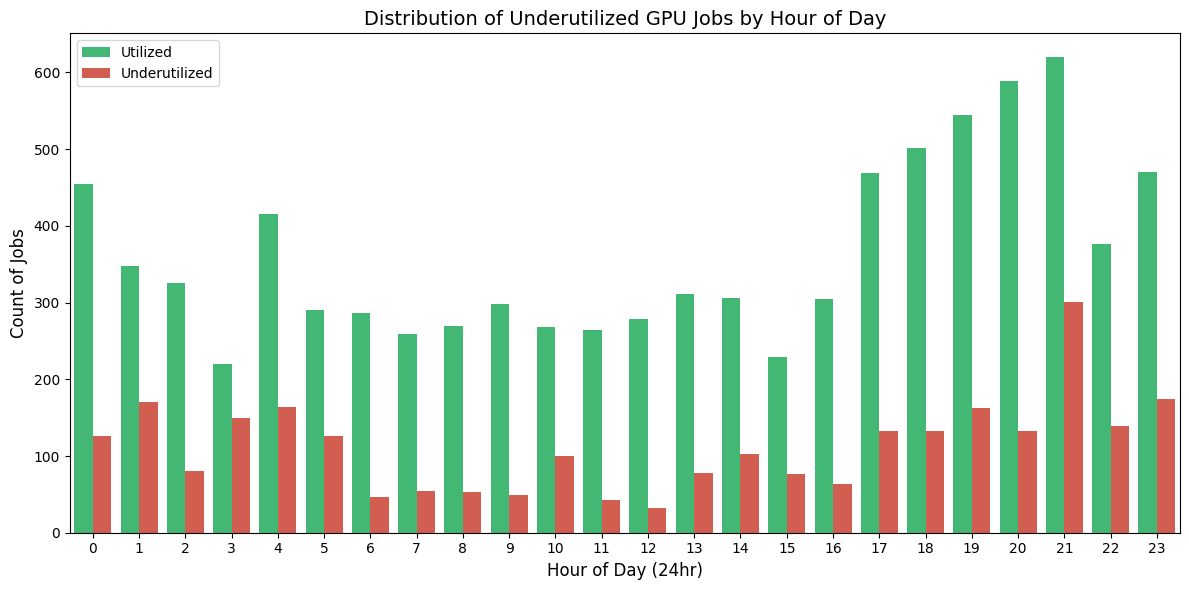

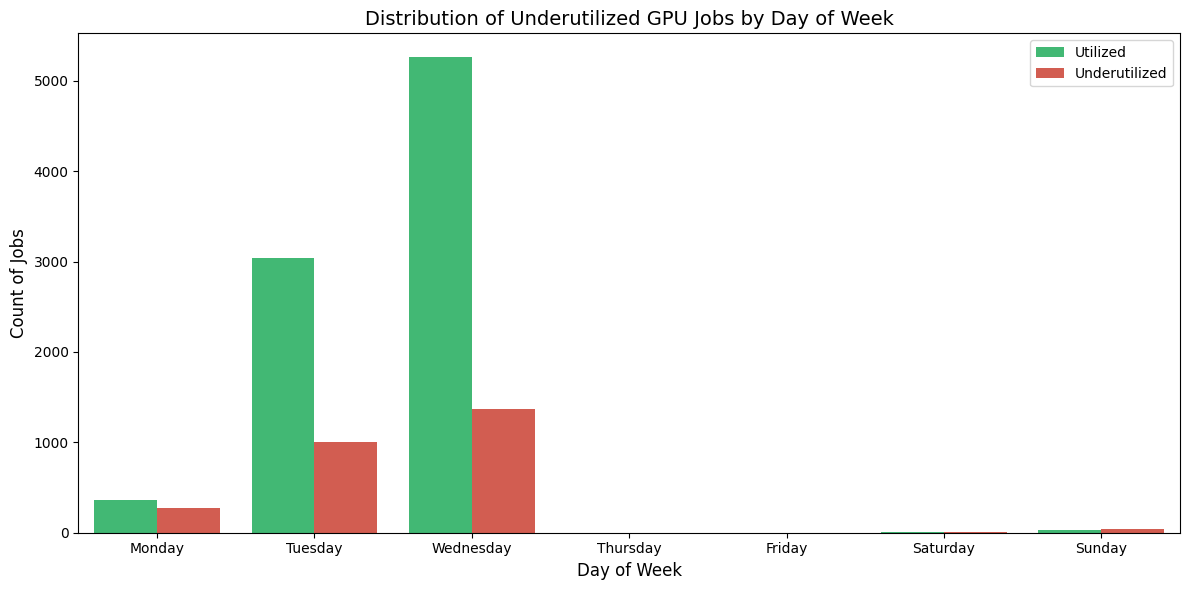

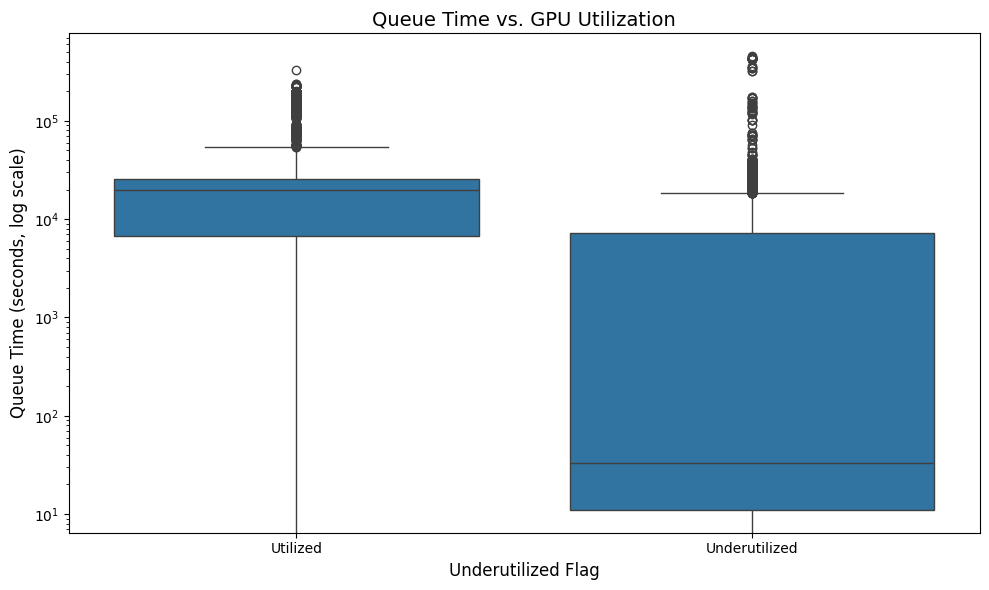

In [23]:
# Visualization 1: Underutilized jobs by time-related metrics
# Create a copy with datetime conversions
gpu_time_analysis = gpu_jobs.copy()

# Convert string times to datetime objects
gpu_time_analysis['SubmitTime'] = pd.to_datetime(gpu_time_analysis['SubmitTime'])
gpu_time_analysis['StartTime'] = pd.to_datetime(gpu_time_analysis['StartTime'])
gpu_time_analysis['EndTime'] = pd.to_datetime(gpu_time_analysis['EndTime'])

# Calculate time in queue (wait time)
gpu_time_analysis['QueueTime'] = (gpu_time_analysis['StartTime'] - gpu_time_analysis['SubmitTime']).dt.total_seconds()

# Extract hour of day and day of week for start time
gpu_time_analysis['StartHour'] = gpu_time_analysis['StartTime'].dt.hour
gpu_time_analysis['StartDayOfWeek'] = gpu_time_analysis['StartTime'].dt.dayofweek

# Plot 1: Underutilized jobs distribution by hour of day
plt.figure(figsize=(12, 6))
ax = sns.countplot(x='StartHour', hue='UnderutilizeFlag', data=gpu_time_analysis, palette=['#2ecc71', '#e74c3c'])
plt.title('Distribution of Underutilized GPU Jobs by Hour of Day', fontsize=14)
plt.xlabel('Hour of Day (24hr)', fontsize=12)
plt.ylabel('Count of Jobs', fontsize=12)
plt.legend(['Utilized', 'Underutilized'])
plt.tight_layout()
plt.show()

# Plot 2: Underutilized jobs distribution by day of week
days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
plt.figure(figsize=(12, 6))
ax = sns.countplot(x='StartDayOfWeek', hue='UnderutilizeFlag', data=gpu_time_analysis, palette=['#2ecc71', '#e74c3c'])
plt.title('Distribution of Underutilized GPU Jobs by Day of Week', fontsize=14)
plt.xlabel('Day of Week', fontsize=12)
plt.ylabel('Count of Jobs', fontsize=12)
plt.xticks(ticks=range(7), labels=days)
plt.legend(['Utilized', 'Underutilized'])
plt.tight_layout()
plt.show()

# Plot 3: Relationship between queue time and underutilization
plt.figure(figsize=(10, 6))
# Log scale for better visualization if there are outliers
sns.boxplot(x='UnderutilizeFlag', y='QueueTime', data=gpu_time_analysis)
plt.title('Queue Time vs. GPU Utilization', fontsize=14)
plt.xlabel('Underutilized Flag', fontsize=12)
plt.ylabel('Queue Time (seconds, log scale)', fontsize=12)
plt.yscale('log')
plt.xticks(ticks=[0, 1], labels=['Utilized', 'Underutilized'])
plt.tight_layout()
plt.show()

/var/folders/wn/4sm351b900qg_5z1gvp_51vw0000gn/T/ipykernel_10095/1434574747.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gpu_jobs['GPU_CPU_Ratio'] = gpu_jobs['GPUs'] / gpu_jobs['CPUs']
/var/folders/wn/4sm351b900qg_5z1gvp_51vw0000gn/T/ipykernel_10095/1434574747.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inpl

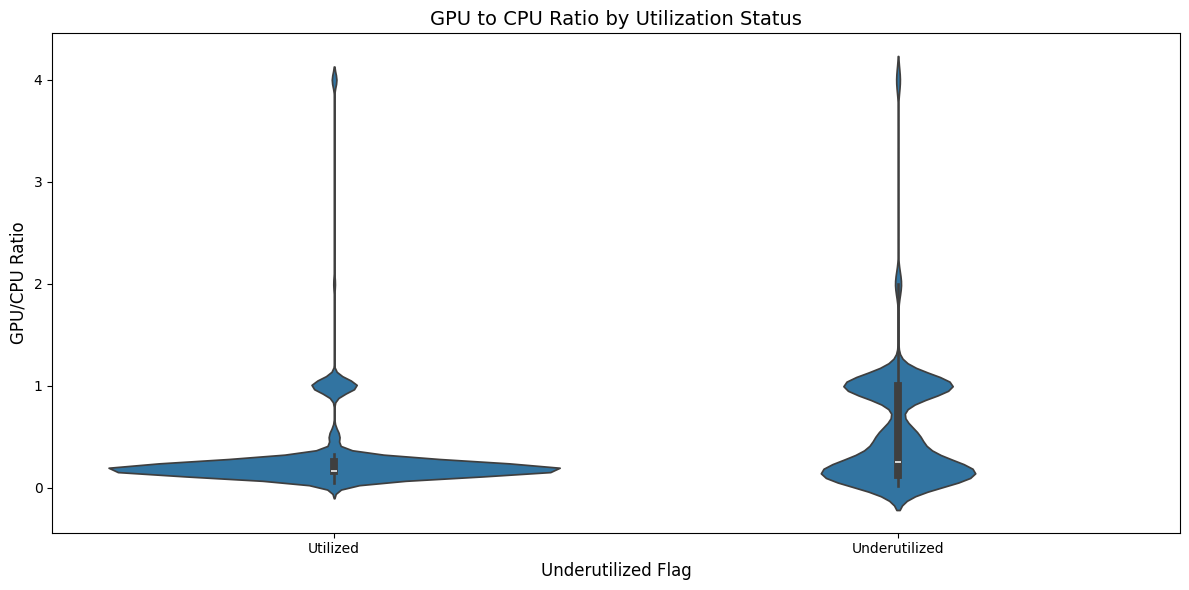

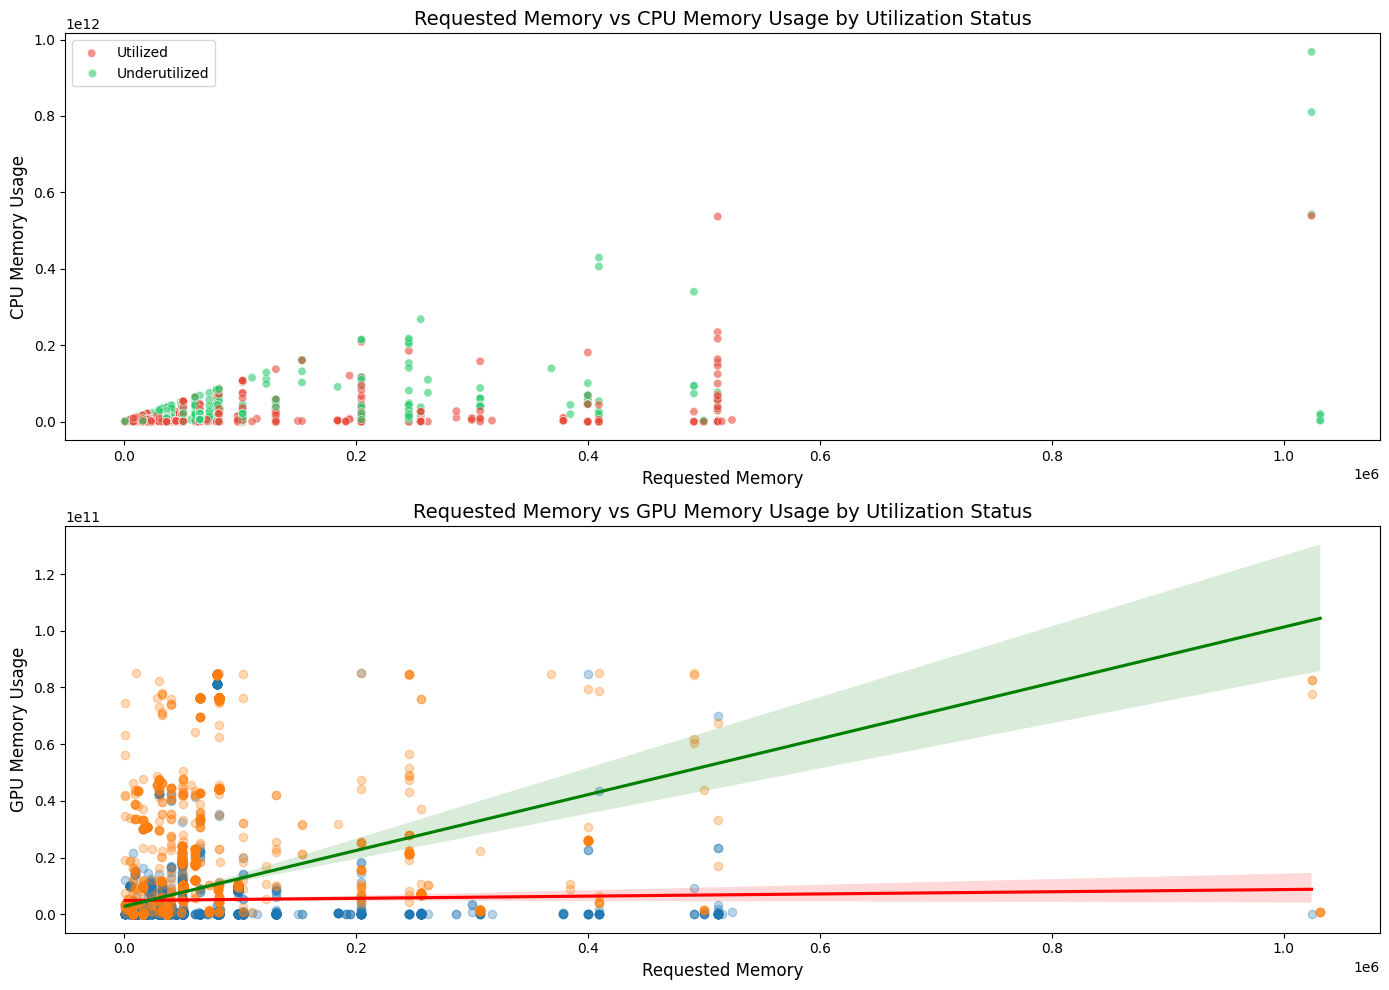

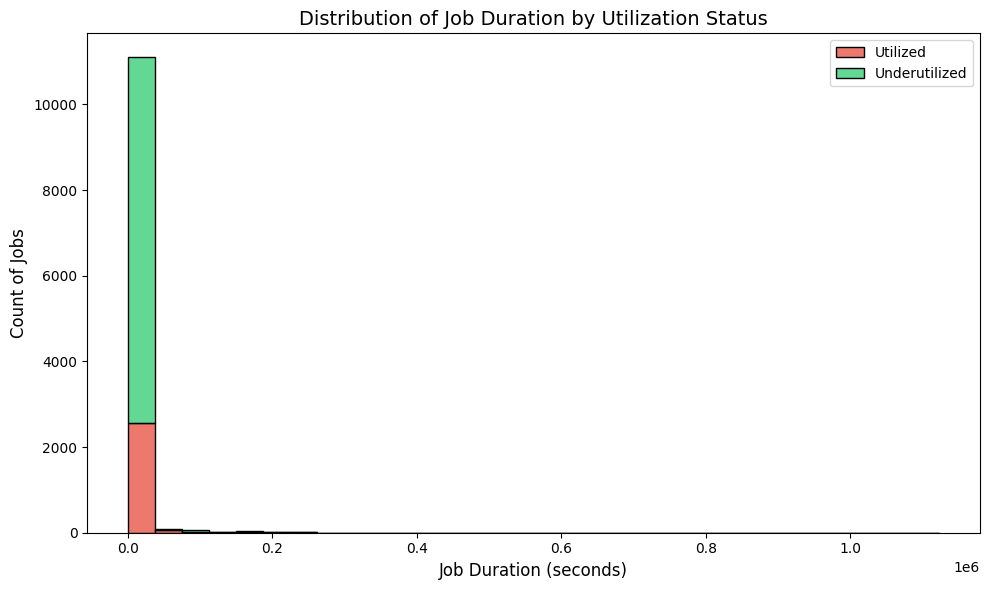

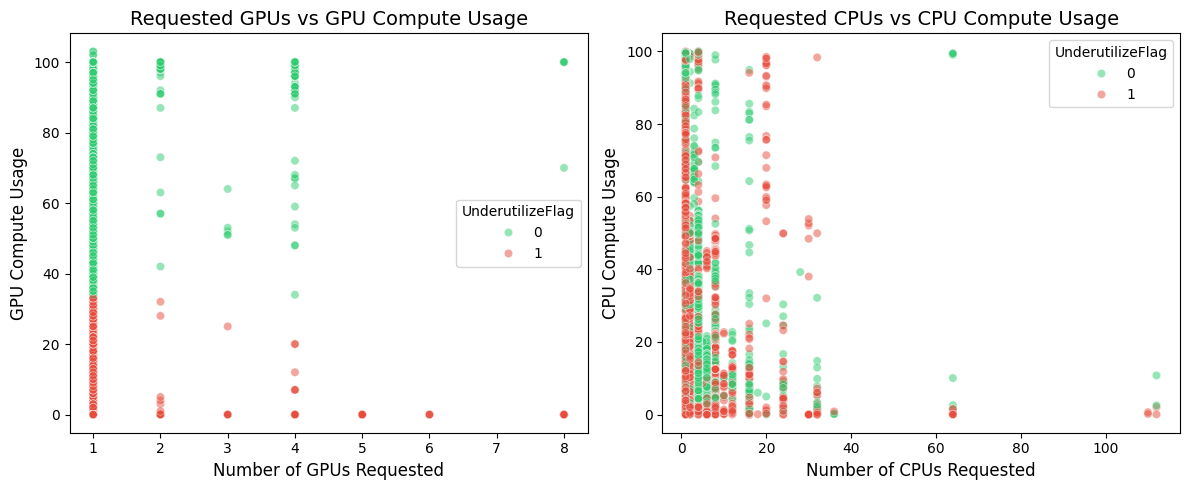

In [24]:
# Visualization 2: Resource allocation patterns in underutilized jobs

# Plot 1: GPU to CPU ratio analysis
gpu_jobs['GPU_CPU_Ratio'] = gpu_jobs['GPUs'] / gpu_jobs['CPUs']
gpu_jobs['GPU_CPU_Ratio'].fillna(0, inplace=True)  # Handle division by zero

plt.figure(figsize=(12, 6))
sns.violinplot(x='UnderutilizeFlag', y='GPU_CPU_Ratio', data=gpu_jobs)
plt.title('GPU to CPU Ratio by Utilization Status', fontsize=14)
plt.xlabel('Underutilized Flag', fontsize=12)
plt.ylabel('GPU/CPU Ratio', fontsize=12)
plt.xticks(ticks=[0, 1], labels=['Utilized', 'Underutilized'])
plt.tight_layout()
plt.show()

# Plot 2: Memory allocation vs utilization
plt.figure(figsize=(14, 10))
plt.subplot(2, 1, 1)
sns.scatterplot(data=gpu_jobs, x='Memory', y='CPUMemUsage', hue='UnderutilizeFlag', 
                palette=['#2ecc71', '#e74c3c'], alpha=0.6)
plt.title('Requested Memory vs CPU Memory Usage by Utilization Status', fontsize=14)
plt.xlabel('Requested Memory', fontsize=12)
plt.ylabel('CPU Memory Usage', fontsize=12)
plt.legend(['Utilized', 'Underutilized'])

plt.subplot(2, 1, 2)
sns.regplot(data=gpu_jobs[gpu_jobs['UnderutilizeFlag']==1], 
            x='Memory', y='GPUMemUsage', 
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
sns.regplot(data=gpu_jobs[gpu_jobs['UnderutilizeFlag']==0], 
            x='Memory', y='GPUMemUsage', 
            scatter_kws={'alpha':0.3}, line_kws={'color':'green'})
plt.title('Requested Memory vs GPU Memory Usage by Utilization Status', fontsize=14)
plt.xlabel('Requested Memory', fontsize=12)
plt.ylabel('GPU Memory Usage', fontsize=12)
plt.tight_layout()
plt.show()

# Plot 3: Job duration distribution by utilization status
plt.figure(figsize=(10, 6))
sns.histplot(data=gpu_jobs, x='Elapsed', hue='UnderutilizeFlag', 
             multiple='stack', bins=30, palette=['#2ecc71', '#e74c3c'])
plt.title('Distribution of Job Duration by Utilization Status', fontsize=14)
plt.xlabel('Job Duration (seconds)', fontsize=12)
plt.ylabel('Count of Jobs', fontsize=12)
plt.legend(['Utilized', 'Underutilized'])
plt.tight_layout()
plt.show()

# Plot 4: Used vs Requested comparison
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.scatterplot(data=gpu_jobs, x='GPUs', y='GPUComputeUsage', 
                hue='UnderutilizeFlag', palette=['#2ecc71', '#e74c3c'], alpha=0.5)
plt.title('Requested GPUs vs GPU Compute Usage', fontsize=14)
plt.xlabel('Number of GPUs Requested', fontsize=12)
plt.ylabel('GPU Compute Usage', fontsize=12)

plt.subplot(1, 2, 2)
sns.scatterplot(data=gpu_jobs, x='CPUs', y='CPUComputeUsage', 
                hue='UnderutilizeFlag', palette=['#2ecc71', '#e74c3c'], alpha=0.5)
plt.title('Requested CPUs vs CPU Compute Usage', fontsize=14)
plt.xlabel('Number of CPUs Requested', fontsize=12)
plt.ylabel('CPU Compute Usage', fontsize=12)
plt.tight_layout()
plt.show()

/var/folders/wn/4sm351b900qg_5z1gvp_51vw0000gn/T/ipykernel_10095/1028159594.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=user_analysis.index[:15], y='UnderutilizeRatio', data=user_analysis.iloc[:15], palette='viridis')


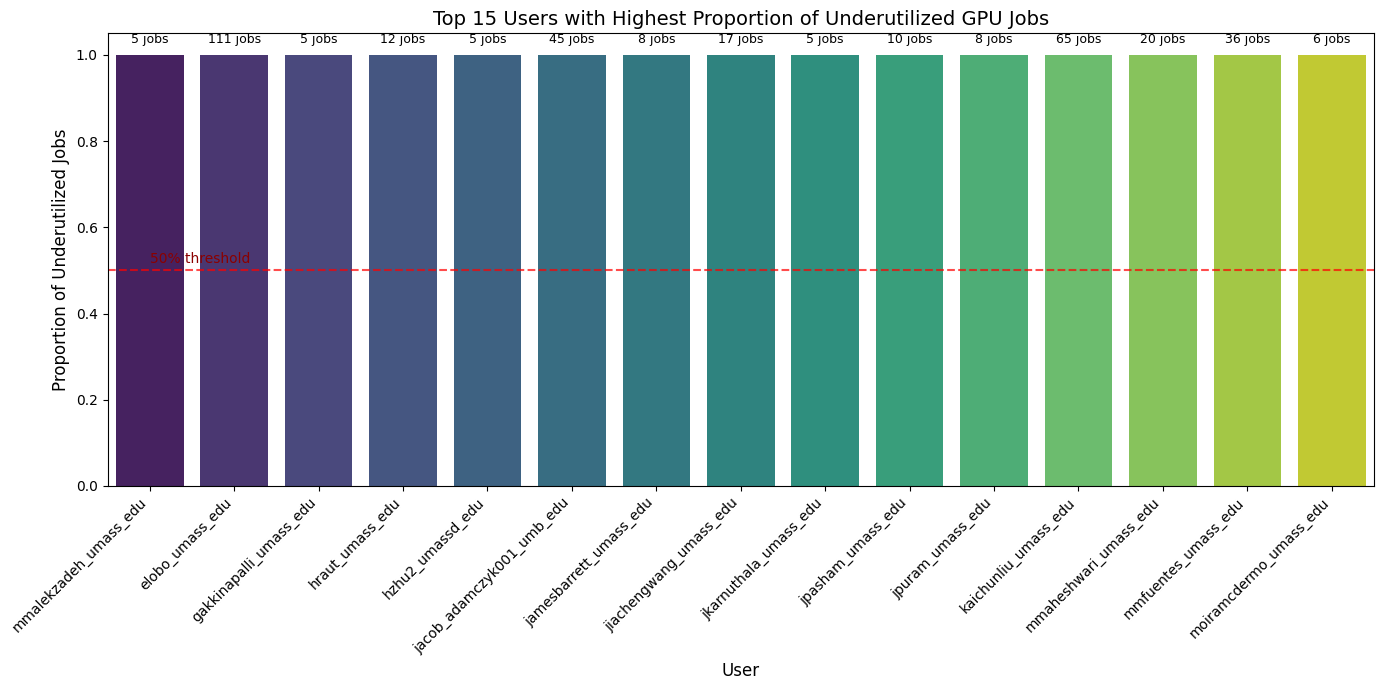

/var/folders/wn/4sm351b900qg_5z1gvp_51vw0000gn/T/ipykernel_10095/1028159594.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(x=partition_analysis.index, y='UnderutilizeRatio', data=partition_analysis, palette='coolwarm')
/var/folders/wn/4sm351b900qg_5z1gvp_51vw0000gn/T/ipykernel_10095/1028159594.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.barplot(x=partition_analysis.index, y='AvgGPUUsage', data=partition_analysis, palette='YlOrRd')


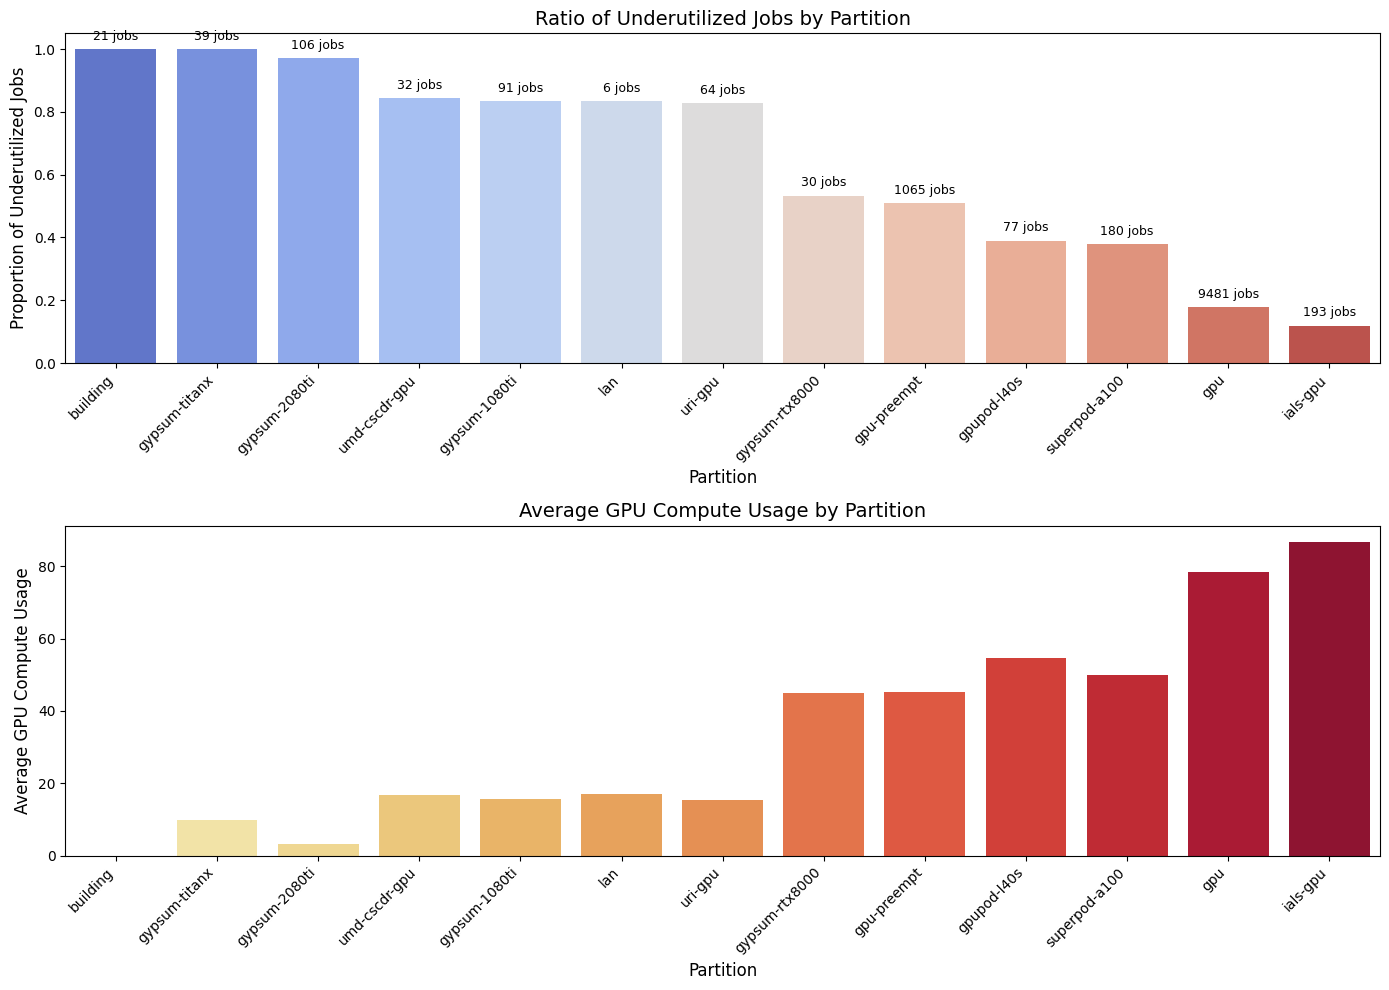

In [25]:
# Visualization 3: User-specific and Partition-specific analysis
# Calculate ratio of underutilized jobs per user
user_underutilize = gpu_jobs.groupby('User')['UnderutilizeFlag'].mean().sort_values(ascending=False)
user_job_counts = gpu_jobs.groupby('User').size()

# Filter for users with at least 5 jobs
user_analysis = pd.DataFrame({
    'UnderutilizeRatio': user_underutilize,
    'TotalJobs': user_job_counts
})
user_analysis = user_analysis[user_analysis['TotalJobs'] >= 5].sort_values('UnderutilizeRatio', ascending=False)

# Plot 1: Top 15 users by ratio of underutilized jobs
plt.figure(figsize=(14, 7))
ax = sns.barplot(x=user_analysis.index[:15], y='UnderutilizeRatio', data=user_analysis.iloc[:15], palette='viridis')
plt.title('Top 15 Users with Highest Proportion of Underutilized GPU Jobs', fontsize=14)
plt.xlabel('User', fontsize=12)
plt.ylabel('Proportion of Underutilized Jobs', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.axhline(y=0.5, color='red', linestyle='--', alpha=0.7)
plt.text(0, 0.51, "50% threshold", va='bottom', ha='left', color='darkred')

# Add job count annotations
for i, p in enumerate(ax.patches):
    user = user_analysis.index[i] if i < len(user_analysis) else ''
    count = user_analysis['TotalJobs'].iloc[i] if i < len(user_analysis) else 0
    ax.annotate(f'{count} jobs', (p.get_x() + p.get_width()/2., p.get_height() + 0.02),
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Plot 2: Partition-specific underutilization analysis
partition_analysis = gpu_jobs.groupby('Partition').agg({
    'UnderutilizeFlag': ['mean', 'count'],
    'GPUComputeUsage': 'mean'
}).sort_values(('UnderutilizeFlag', 'mean'), ascending=False)

partition_analysis.columns = ['UnderutilizeRatio', 'JobCount', 'AvgGPUUsage']
partition_analysis = partition_analysis[partition_analysis['JobCount'] >= 5]

plt.figure(figsize=(14, 10))
plt.subplot(2, 1, 1)
ax1 = sns.barplot(x=partition_analysis.index, y='UnderutilizeRatio', data=partition_analysis, palette='coolwarm')
plt.title('Ratio of Underutilized Jobs by Partition', fontsize=14)
plt.xlabel('Partition', fontsize=12)
plt.ylabel('Proportion of Underutilized Jobs', fontsize=12)
plt.xticks(rotation=45, ha='right')

plt.subplot(2, 1, 2)
ax2 = sns.barplot(x=partition_analysis.index, y='AvgGPUUsage', data=partition_analysis, palette='YlOrRd')
plt.title('Average GPU Compute Usage by Partition', fontsize=14)
plt.xlabel('Partition', fontsize=12)
plt.ylabel('Average GPU Compute Usage', fontsize=12)
plt.xticks(rotation=45, ha='right')

# Annotate with job counts
for i, p in enumerate(ax1.patches):
    partition = partition_analysis.index[i] if i < len(partition_analysis) else ''
    count = partition_analysis['JobCount'].iloc[i] if i < len(partition_analysis) else 0
    ax1.annotate(f'{count} jobs', (p.get_x() + p.get_width()/2., p.get_height() + 0.02),
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

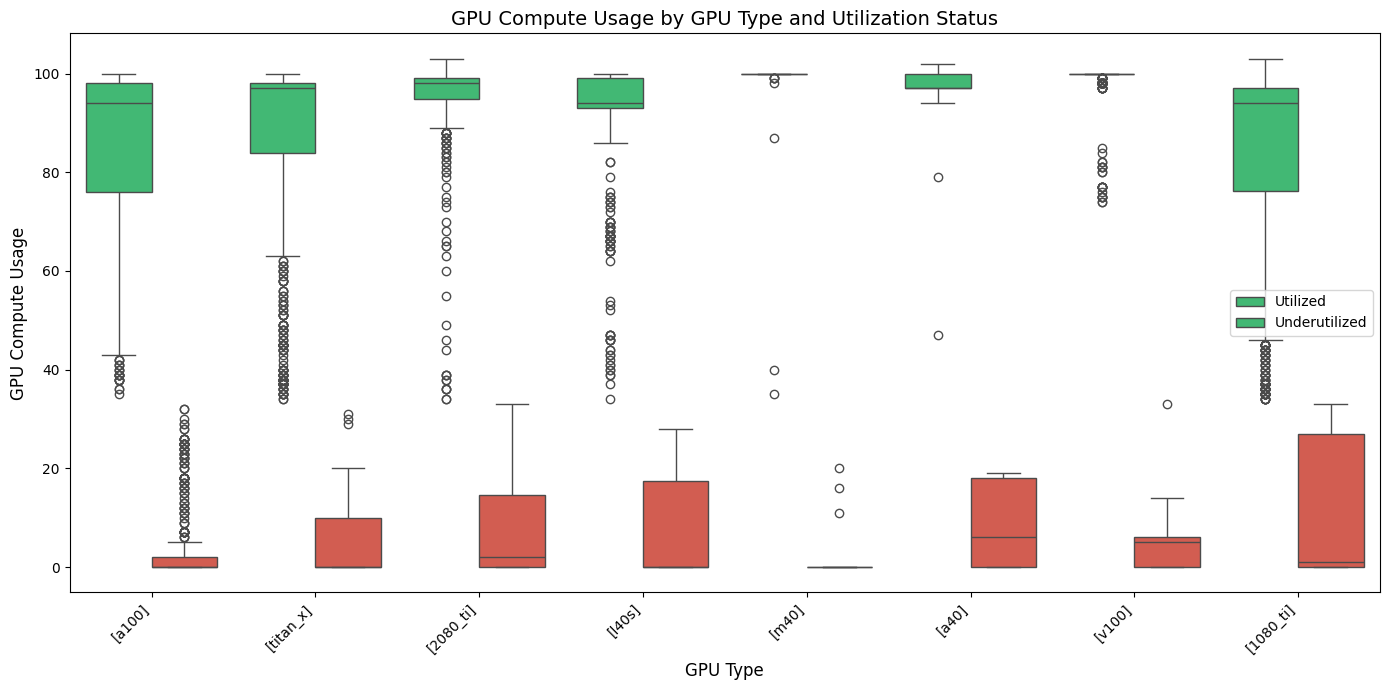

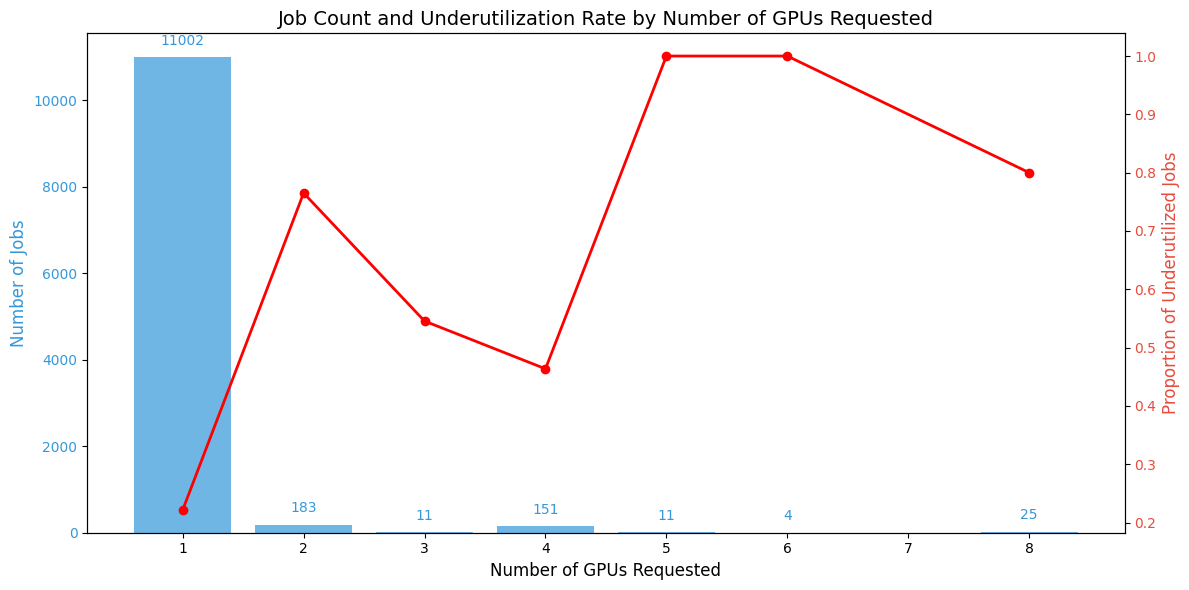

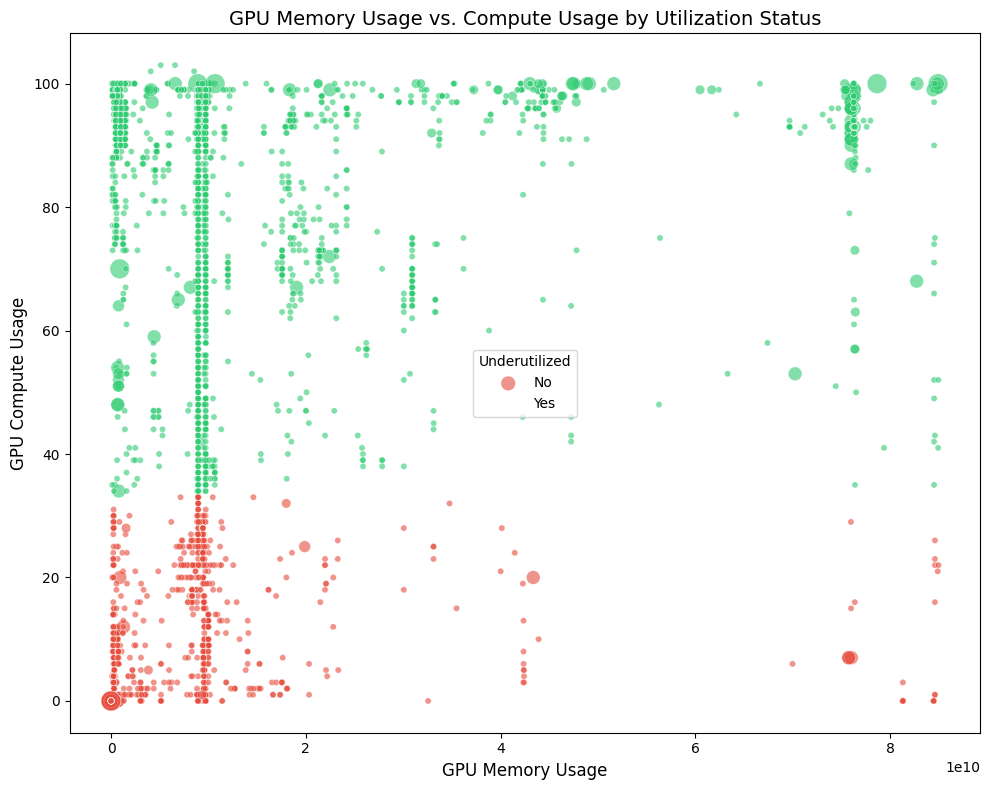

In [26]:
# Visualization 4: GPU Type Analysis and Job Efficiency Metrics

# Plot 1: GPU Type vs. Utilization
plt.figure(figsize=(14, 7))
# Filter to top 8 GPU types for readability
top_gpu_types = gpu_jobs['GPUType'].value_counts().head(8).index
gpu_type_data = gpu_jobs[gpu_jobs['GPUType'].isin(top_gpu_types)]

ax = sns.boxplot(x='GPUType', y='GPUComputeUsage', hue='UnderutilizeFlag', 
                data=gpu_type_data, palette=['#2ecc71', '#e74c3c'])
plt.title('GPU Compute Usage by GPU Type and Utilization Status', fontsize=14)
plt.xlabel('GPU Type', fontsize=12)
plt.ylabel('GPU Compute Usage', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(['Utilized', 'Underutilized'])
plt.tight_layout()
plt.show()

# Plot 2: Job Size Analysis - GPU count vs Utilization
gpu_count_util = gpu_jobs.groupby('GPUs')['UnderutilizeFlag'].mean()
gpu_count_jobs = gpu_jobs.groupby('GPUs').size()

# Create a job count vs. underutilization plot
fig, ax1 = plt.subplots(figsize=(12, 6))

# Bar chart showing job counts by GPU count
ax1.bar(gpu_count_jobs.index, gpu_count_jobs.values, color='#3498db', alpha=0.7)
ax1.set_xlabel('Number of GPUs Requested', fontsize=12)
ax1.set_ylabel('Number of Jobs', fontsize=12, color='#3498db')
ax1.tick_params(axis='y', labelcolor='#3498db')

# Add a second y-axis for underutilization rate
ax2 = ax1.twinx()
ax2.plot(gpu_count_util.index, gpu_count_util.values, 'ro-', linewidth=2)
ax2.set_ylabel('Proportion of Underutilized Jobs', fontsize=12, color='#e74c3c')
ax2.tick_params(axis='y', labelcolor='#e74c3c')
ax2.grid(False)

# Add annotations for job counts
for i, count in enumerate(gpu_count_jobs.values):
    ax1.annotate(f'{count}', (gpu_count_jobs.index[i], count + max(gpu_count_jobs.values)*0.02),
                ha='center', va='bottom', fontsize=10, color='#3498db')

plt.title('Job Count and Underutilization Rate by Number of GPUs Requested', fontsize=14)
plt.tight_layout()
plt.show()

# Plot 3: GPUMemUsage vs. GPUComputeUsage scatter with utilization flag
plt.figure(figsize=(10, 8))
sns.scatterplot(data=gpu_jobs, 
                x='GPUMemUsage', y='GPUComputeUsage', 
                hue='UnderutilizeFlag',
                palette=['#2ecc71', '#e74c3c'],
                size='GPUs',  # Size by number of GPUs
                sizes=(20, 200),
                alpha=0.6)
plt.title('GPU Memory Usage vs. Compute Usage by Utilization Status', fontsize=14)
plt.xlabel('GPU Memory Usage', fontsize=12)
plt.ylabel('GPU Compute Usage', fontsize=12)
plt.legend(title='Underutilized', labels=['No', 'Yes'])
plt.tight_layout()
plt.show()

/var/folders/wn/4sm351b900qg_5z1gvp_51vw0000gn/T/ipykernel_10095/3906063827.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gpu_jobs['JobEfficiency'] = gpu_jobs['GPUComputeUsage'] / (gpu_jobs['GPUs'] * 100)  # Normalize by GPU count
/var/folders/wn/4sm351b900qg_5z1gvp_51vw0000gn/T/ipykernel_10095/3906063827.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(

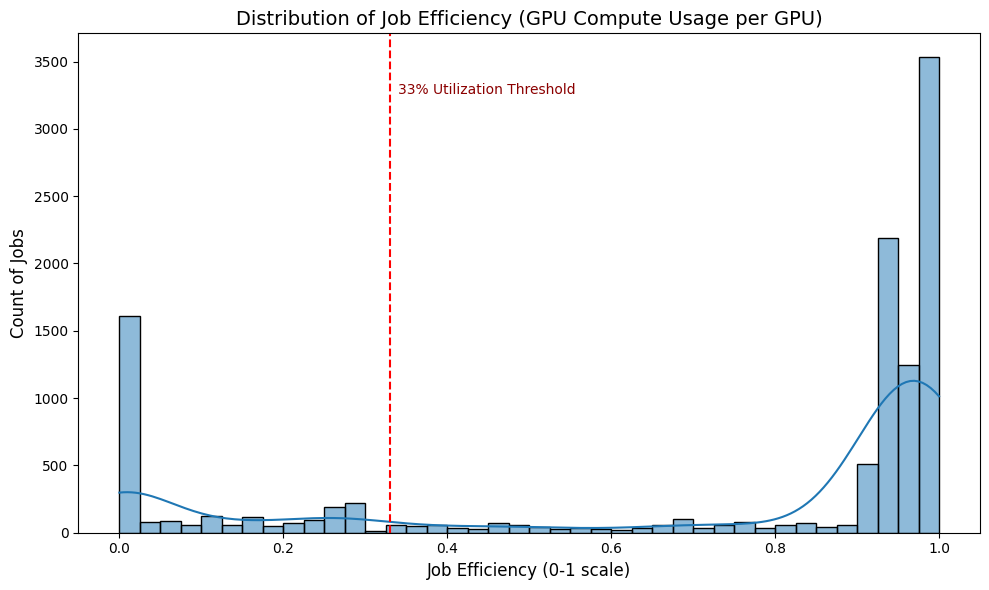

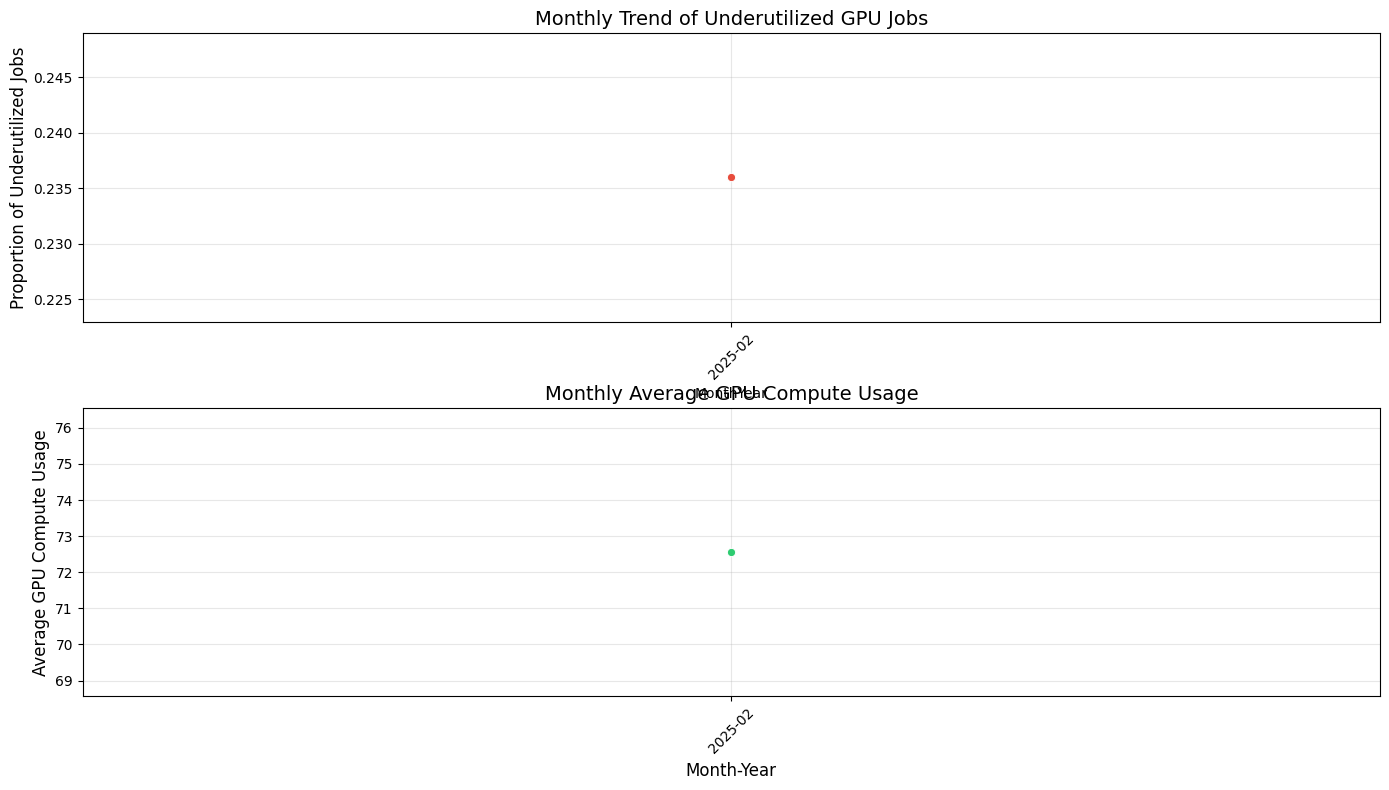

/var/folders/wn/4sm351b900qg_5z1gvp_51vw0000gn/T/ipykernel_10095/3906063827.py:55: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gpu_jobs['DurationCategory'] = pd.cut(


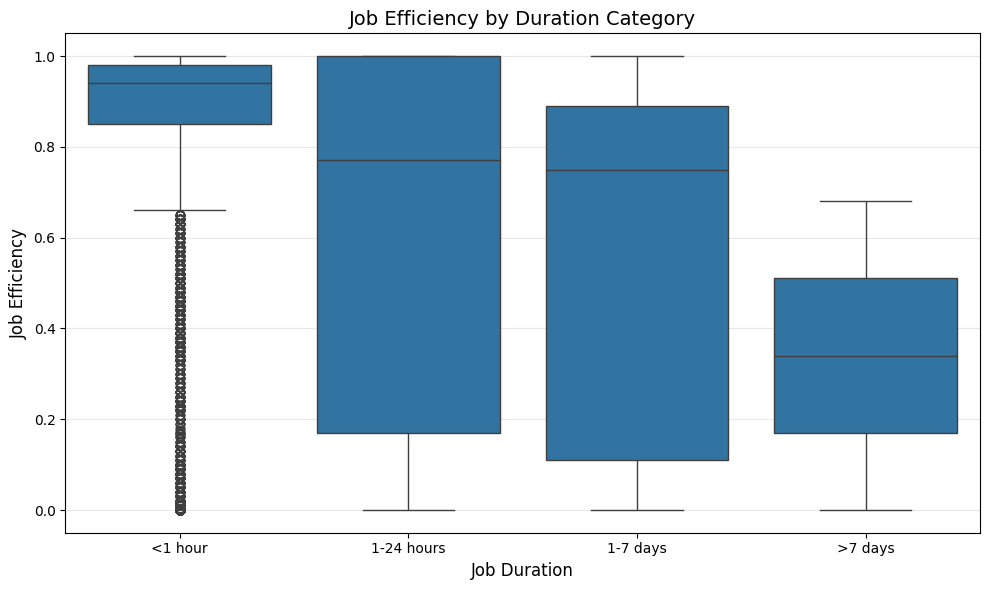

In [27]:
# Visualization 5: Job Efficiency Analysis and Temporal Patterns

# Calculate job efficiency metrics
gpu_jobs['JobEfficiency'] = gpu_jobs['GPUComputeUsage'] / (gpu_jobs['GPUs'] * 100)  # Normalize by GPU count
gpu_jobs['JobEfficiency'].fillna(0, inplace=True)  # Handle NA values
gpu_jobs['JobEfficiency'] = gpu_jobs['JobEfficiency'].clip(0, 1)  # Clip between 0 and 1

# Add month and quarter columns for temporal analysis
gpu_time_analysis['Month'] = gpu_time_analysis['StartTime'].dt.month
gpu_time_analysis['Quarter'] = gpu_time_analysis['StartTime'].dt.quarter
gpu_time_analysis['Year'] = gpu_time_analysis['StartTime'].dt.year

# Plot 1: Job efficiency distribution
plt.figure(figsize=(10, 6))
sns.histplot(data=gpu_jobs, x='JobEfficiency', bins=40, kde=True)
plt.axvline(x=0.33, color='red', linestyle='--')
plt.text(0.34, plt.ylim()[1]*0.9, "33% Utilization Threshold", va='top', color='darkred')
plt.title('Distribution of Job Efficiency (GPU Compute Usage per GPU)', fontsize=14)
plt.xlabel('Job Efficiency (0-1 scale)', fontsize=12)
plt.ylabel('Count of Jobs', fontsize=12)
plt.tight_layout()
plt.show()

# Plot 2: Temporal trends in GPU utilization
monthly_util = gpu_time_analysis.groupby(['Year', 'Month']).agg({
    'UnderutilizeFlag': 'mean',
    'GPUComputeUsage': 'mean',
    'JobID': 'count'  # Count of jobs
}).reset_index()

# Create month-year labels for x-axis
monthly_util['MonthYear'] = monthly_util['Year'].astype(str) + '-' + monthly_util['Month'].astype(str).str.zfill(2)

plt.figure(figsize=(14, 8))
ax1 = plt.subplot(2, 1, 1)
sns.lineplot(data=monthly_util, x='MonthYear', y='UnderutilizeFlag', marker='o', color='#e74c3c', linewidth=2)
plt.title('Monthly Trend of Underutilized GPU Jobs', fontsize=14)
plt.ylabel('Proportion of Underutilized Jobs', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

ax2 = plt.subplot(2, 1, 2, sharex=ax1)
sns.lineplot(data=monthly_util, x='MonthYear', y='GPUComputeUsage', marker='o', color='#2ecc71', linewidth=2)
plt.title('Monthly Average GPU Compute Usage', fontsize=14)
plt.xlabel('Month-Year', fontsize=12)
plt.ylabel('Average GPU Compute Usage', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()
plt.subplots_adjust(hspace=0.3)
plt.show()

# Plot 3: Efficiency by job duration categories
gpu_jobs['DurationCategory'] = pd.cut(
    gpu_jobs['Elapsed'],
    bins=[0, 3600, 86400, 604800, float('inf')],  # 1hr, 1day, 1week, >1week
    labels=['<1 hour', '1-24 hours', '1-7 days', '>7 days']
)

plt.figure(figsize=(10, 6))
sns.boxplot(data=gpu_jobs, x='DurationCategory', y='JobEfficiency')
plt.title('Job Efficiency by Duration Category', fontsize=14)
plt.xlabel('Job Duration', fontsize=12)
plt.ylabel('Job Efficiency', fontsize=12)
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

/var/folders/wn/4sm351b900qg_5z1gvp_51vw0000gn/T/ipykernel_10095/1537465168.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gpu_jobs['CPUUtil_per_CPU'] = gpu_jobs['CPUComputeUsage'] / gpu_jobs['CPUs']
/var/folders/wn/4sm351b900qg_5z1gvp_51vw0000gn/T/ipykernel_10095/1537465168.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gpu_jobs['GPUUtil_per_GPU'] = gpu_jobs['GPUComputeUsage'] / gpu_jobs['GPUs']
/var/folders/wn/4sm351b900qg_5z1gvp_51vw0000gn/T/ipykernel_10095/1537465168.py:6: SettingWithCopyWarni

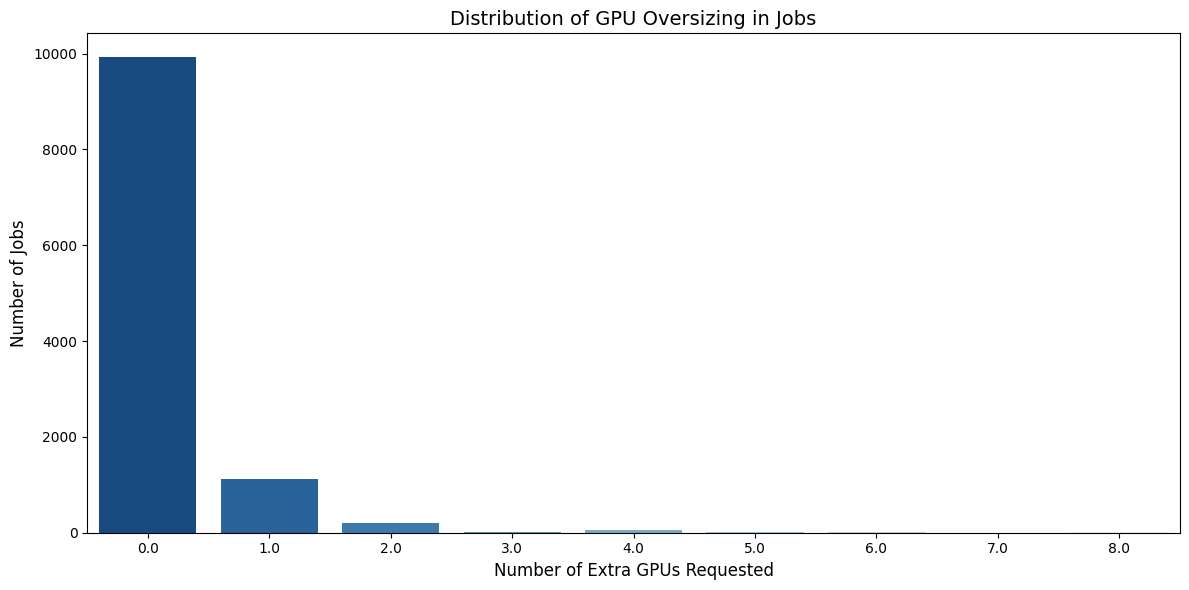

/var/folders/wn/4sm351b900qg_5z1gvp_51vw0000gn/T/ipykernel_10095/1537465168.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='GPUs', y='Potential_Savings_Rate', data=gpu_savings, palette='viridis')


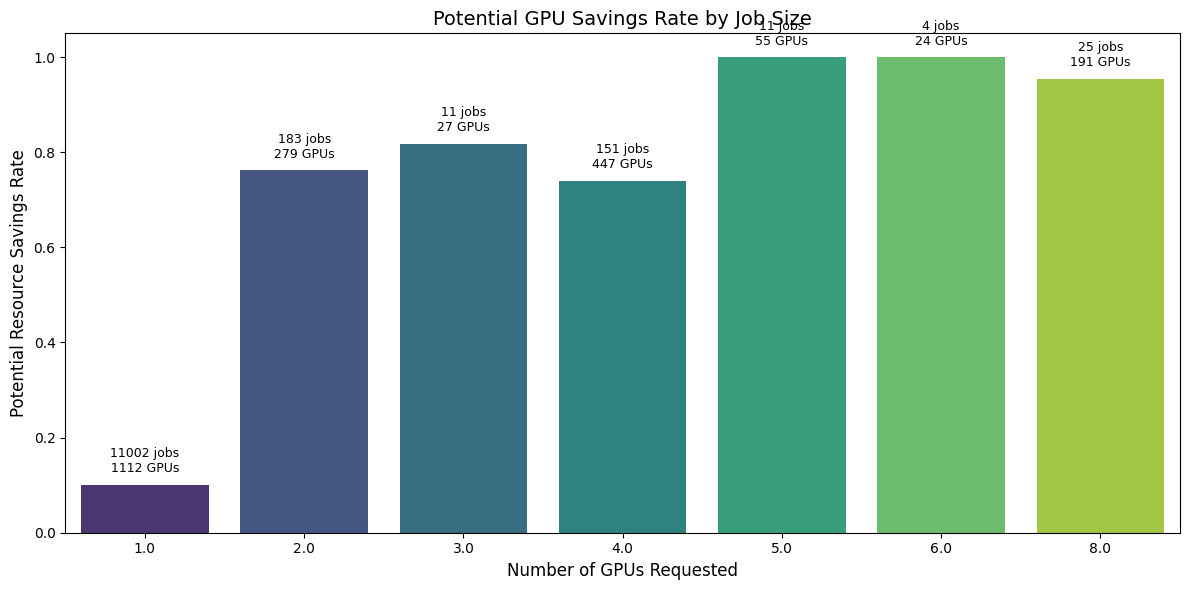

/var/folders/wn/4sm351b900qg_5z1gvp_51vw0000gn/T/ipykernel_10095/1537465168.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='GPUType', y='GPUUtil_per_GPU', data=gpu_jobs[gpu_jobs['GPUType'].isin(top_gpu_types)], palette='viridis')


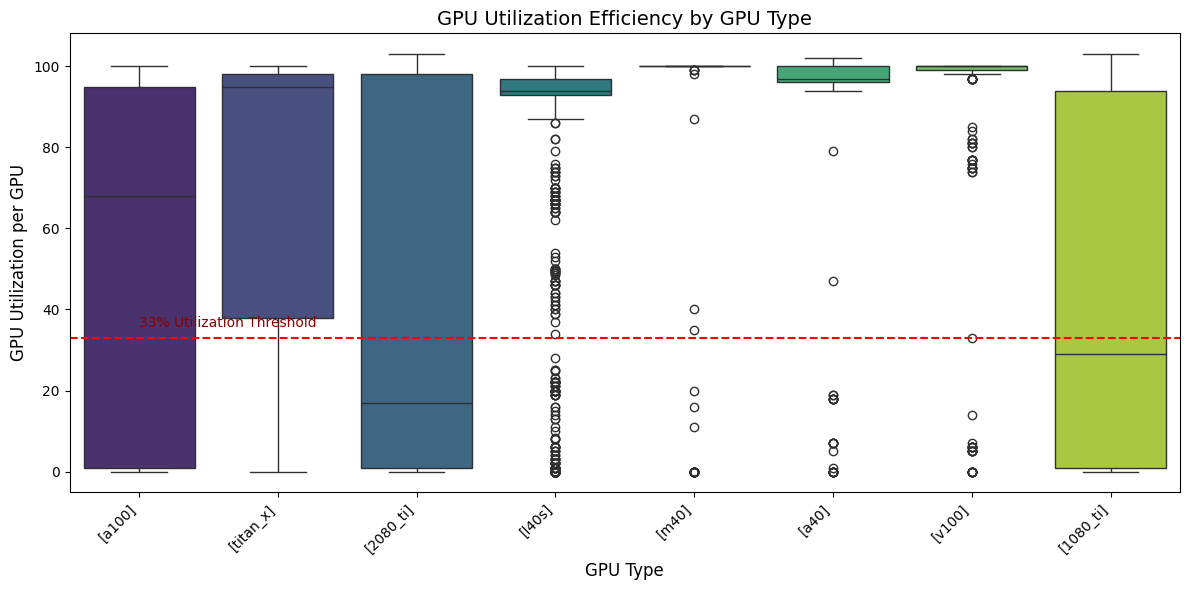

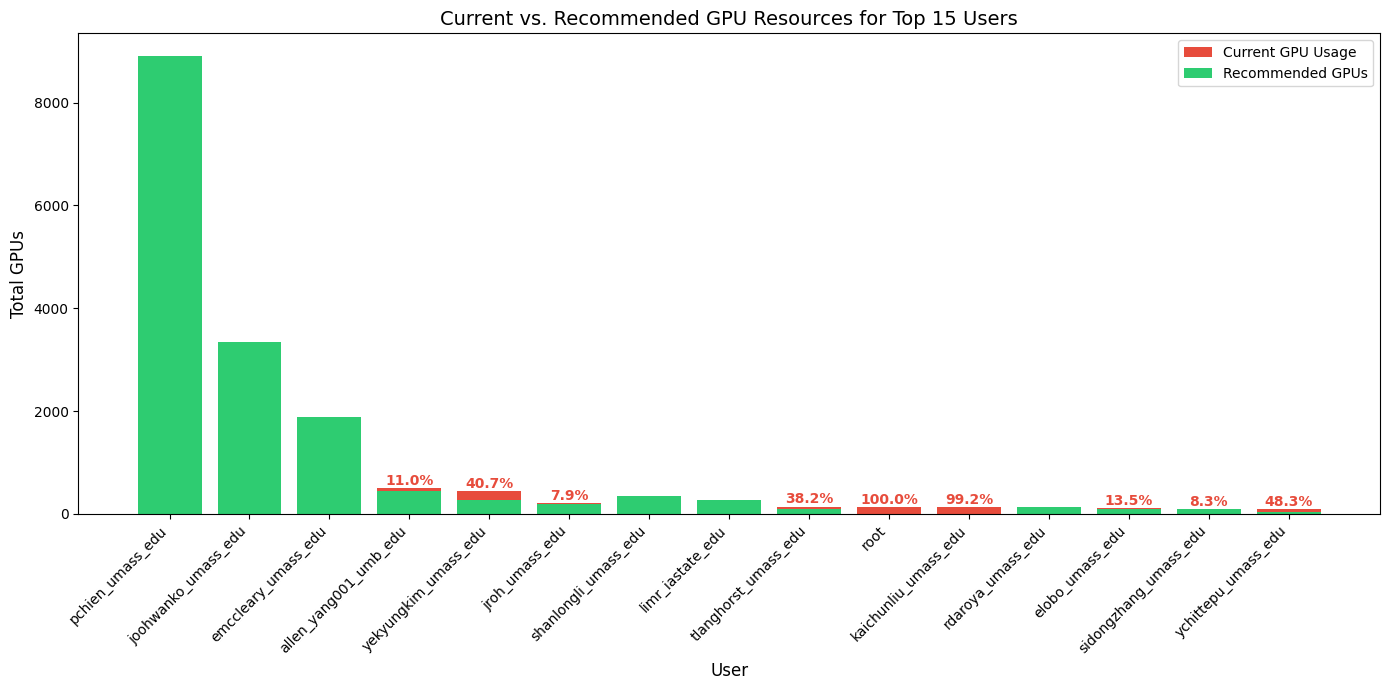

In [28]:
# Visualization 6: Resource Recommendation Analysis

# Calculate the resource optimization metrics
gpu_jobs['CPUUtil_per_CPU'] = gpu_jobs['CPUComputeUsage'] / gpu_jobs['CPUs']
gpu_jobs['GPUUtil_per_GPU'] = gpu_jobs['GPUComputeUsage'] / gpu_jobs['GPUs']
gpu_jobs['MemUtil_Ratio'] = gpu_jobs['CPUMemUsage'] / gpu_jobs['Memory']

# Calculate recommended resources based on actual usage
# Using 80% utilization as an optimal target
gpu_jobs['Recommended_GPUs'] = np.ceil(gpu_jobs['GPUComputeUsage'] / 80)
gpu_jobs['GPU_Oversizing'] = gpu_jobs['GPUs'] - gpu_jobs['Recommended_GPUs']
gpu_jobs['GPU_Oversizing'] = gpu_jobs['GPU_Oversizing'].clip(lower=0)  # Don't show negative values

# Plot 1: GPU oversizing distribution
plt.figure(figsize=(12, 6))
sns.countplot(data=gpu_jobs, x='GPU_Oversizing', palette='Blues_r')
plt.title('Distribution of GPU Oversizing in Jobs', fontsize=14)
plt.xlabel('Number of Extra GPUs Requested', fontsize=12)
plt.ylabel('Number of Jobs', fontsize=12)
plt.tight_layout()
plt.show()

# Plot 2: Potential resource savings
# Group by number of GPUs requested
gpu_savings = gpu_jobs.groupby('GPUs').agg({
    'GPU_Oversizing': 'sum',
    'JobID': 'count'
}).reset_index()
gpu_savings['Avg_Oversizing_per_Job'] = gpu_savings['GPU_Oversizing'] / gpu_savings['JobID']
gpu_savings['Potential_Savings_Rate'] = gpu_savings['GPU_Oversizing'] / (gpu_savings['GPUs'] * gpu_savings['JobID'])

plt.figure(figsize=(12, 6))
ax = sns.barplot(x='GPUs', y='Potential_Savings_Rate', data=gpu_savings, palette='viridis')
plt.title('Potential GPU Savings Rate by Job Size', fontsize=14)
plt.xlabel('Number of GPUs Requested', fontsize=12)
plt.ylabel('Potential Resource Savings Rate', fontsize=12)

# Add annotations
for i, p in enumerate(ax.patches):
    count = int(gpu_savings['JobID'].iloc[i])
    waste = int(gpu_savings['GPU_Oversizing'].iloc[i])
    ax.annotate(f'{count} jobs\n{waste} GPUs', 
                (p.get_x() + p.get_width()/2., p.get_height() + 0.02),
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Plot 3: Resource utilization by GPU type
plt.figure(figsize=(12, 6))
sns.boxplot(x='GPUType', y='GPUUtil_per_GPU', data=gpu_jobs[gpu_jobs['GPUType'].isin(top_gpu_types)], palette='viridis')
plt.title('GPU Utilization Efficiency by GPU Type', fontsize=14)
plt.xlabel('GPU Type', fontsize=12)
plt.ylabel('GPU Utilization per GPU', fontsize=12)
plt.axhline(y=33, color='red', linestyle='--')
plt.text(0, 35, "33% Utilization Threshold", va='bottom', color='darkred')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Plot 4: Optimized resource recommendations
optimized_resources = gpu_jobs.groupby('User').agg({
    'GPUs': 'sum',
    'Recommended_GPUs': 'sum'
}).reset_index()
optimized_resources = optimized_resources.sort_values(by='GPUs', ascending=False).head(15)
optimized_resources['Potential_Savings'] = optimized_resources['GPUs'] - optimized_resources['Recommended_GPUs']
optimized_resources['Savings_Percent'] = (optimized_resources['Potential_Savings'] / optimized_resources['GPUs']) * 100

plt.figure(figsize=(14, 7))
plt.bar(optimized_resources['User'], optimized_resources['GPUs'], color='#e74c3c', label='Current GPU Usage')
plt.bar(optimized_resources['User'], optimized_resources['Recommended_GPUs'], color='#2ecc71', label='Recommended GPUs')
plt.title('Current vs. Recommended GPU Resources for Top 15 Users', fontsize=14)
plt.xlabel('User', fontsize=12)
plt.ylabel('Total GPUs', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend()

# Add savings percentage annotations
for i, user in enumerate(optimized_resources['User']):
    savings = optimized_resources['Savings_Percent'].iloc[i]
    if savings > 0:
        plt.text(i, optimized_resources['GPUs'].iloc[i] + 1, 
                 f"{savings:.1f}%", ha='center', va='bottom',
                 color='#e74c3c', fontweight='bold')

plt.tight_layout()
plt.show()

## Advanced Analysis: Predictive Modeling for GPU Job Utilization

Let's develop a machine learning model to predict which jobs are likely to underutilize GPUs before they run, based on the available features at job submission time. This could potentially help with job scheduling optimization and resource allocation.

### Preprocessing Pipeline for Predictive Modeling

The comprehensive preprocessing pipeline we've established above will now be applied specifically to features available at **job submission time**. This ensures our predictive model can make real-time predictions to help with job scheduling optimization.

**Key Distinction:**
- **Comprehensive pipeline**: Uses all available features including job execution metrics (for analysis)
- **Prediction pipeline**: Uses only submission-time features (for real-time prediction)

This approach enables practical deployment where we can predict GPU underutilization before jobs actually run.

In [42]:
# Building a predictive model for GPU underutilization
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score
from sklearn.impute import SimpleImputer
try:
    import xgboost as xgb
    XGBOOST_AVAILABLE = True
    print("✓ XGBoost successfully imported")
except ImportError:
    XGBOOST_AVAILABLE = False
    print("⚠️  XGBoost not installed. Install with: pip install xgboost")
except Exception as e:
    XGBOOST_AVAILABLE = False
    error_msg = str(e)
    print("⚠️  XGBoost import failed due to dependency issues:")
    print(f"Error: {error_msg}")
    
    # Provide specific guidance for common macOS OpenMP issues
    if "libomp" in error_msg and "darwin" in error_msg.lower():
        print("\n🔧 macOS Fix: Install OpenMP library using Homebrew:")
        print("   brew install libomp")
        print("   Then restart your notebook kernel")
    elif "libomp" in error_msg:
        print("\n🔧 OpenMP library missing. Try one of these solutions:")
        print("   • macOS: brew install libomp")
        print("   • conda: conda install -c conda-forge compilers")
        print("   • Alternative: Use LightGBM instead of XGBoost")
    
    print("\n💡 Continuing without XGBoost - RandomForest and GradientBoosting are still available")


✓ XGBoost successfully imported


### 🔧 Fixing XGBoost Installation Issues

If you encounter XGBoost import errors (especially on macOS), here are the solutions:

#### For macOS OpenMP Library Issues:
```bash
# Install OpenMP library via Homebrew
brew install libomp

# Restart your Jupyter notebook kernel after installation
```

#### Alternative Solutions:
1. **Use conda instead**: `conda install -c conda-forge xgboost`
2. **Use LightGBM**: `pip install lightgbm` (similar performance to XGBoost)
3. **Continue without XGBoost**: RandomForest and GradientBoosting work perfectly

#### For other systems:
- **Ubuntu/Debian**: `sudo apt-get install libomp-dev`
- **CentOS/RHEL**: `sudo yum install libgomp`

The notebook will automatically detect available libraries and adapt accordingly.

In [46]:

print("Preparing data for predictive modeling...")

# Select features available at job submission time (not using actual usage metrics for prediction)
submission_features = [
    'CPUs', 'Memory', 'GPUs', 'TimeLimit',  # Resources requested
    'Partition', 'GPUType',  # Job configuration
    'Account', 'User'  # User/group identifiers
]

# Filter out rows with missing required fields
model_data = gpu_jobs.dropna(subset=['UnderutilizeFlag']).copy()



Preparing data for predictive modeling...


In [49]:

# Extract features that would be available at submission time
X = model_data[submission_features]
y = model_data['UnderutilizeFlag']
y

6        1
7        1
8        1
9        1
10       1
        ..
34195    0
34196    1
34197    1
34198    1
34199    1
Name: UnderutilizeFlag, Length: 11387, dtype: int64

#### There are users and Account named root? 

In [63]:

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} jobs")
print(f"Test set size: {X_test.shape[0]} jobs")
print(f"Underutilized jobs ratio in training data: {100 * y_train.mean():.1f}%")

# Create preprocessor for numerical and categorical features (for job submission prediction)
submission_numerical_features = ['CPUs', 'Memory', 'GPUs', 'TimeLimit']
submission_categorical_features = ['Partition', 'GPUType', 'Account', 'User']


Training set size: 9109 jobs
Test set size: 2278 jobs
Underutilized jobs ratio in training data: 23.7%


In [64]:

# Create a flexible preprocessing function that can handle any subset of features
def create_flexible_preprocessor(data_columns):
    """
    Create a preprocessor that adapts to the available columns in the data.
    Only includes transformers for columns that actually exist in the data.
    """
    # Find which numerical and categorical features are actually in the data
    available_numerical = [col for col in submission_numerical_features if col in data_columns]
    available_categorical = [col for col in submission_categorical_features if col in data_columns]
    
    transformers = []
    
    # Add numerical transformer only if we have numerical features
    if available_numerical:
        transformers.append(
            ('num', Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())
            ]), available_numerical)
        )
    
    # Add categorical transformer only if we have categorical features
    if available_categorical:
        transformers.append(
            ('cat', Pipeline([
                ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
                ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
            ]), available_categorical)
        )
    
    if not transformers:
        raise ValueError("No valid numerical or categorical features found in the data!")
    
    return ColumnTransformer(transformers=transformers, remainder='drop')

# Handle both numerical and categorical features for predictive modeling
# This is the main preprocessor for the full feature set
prediction_preprocessor = create_flexible_preprocessor(submission_numerical_features + submission_categorical_features)

print("Flexible preprocessing pipeline for predictive modeling created successfully!")
print(f"Available numerical features: {submission_numerical_features}")
print(f"Available categorical features: {submission_categorical_features}")

Flexible preprocessing pipeline for predictive modeling created successfully!
Available numerical features: ['CPUs', 'Memory', 'GPUs', 'TimeLimit']
Available categorical features: ['Partition', 'GPUType', 'Account', 'User']


In [65]:
# Demonstrate the preprocessing pipeline with a sample of our data
print("Demonstrating preprocessing pipeline with sample data...")

# Select a subset of features for demonstration
demo_features = submission_numerical_features + submission_categorical_features[:3]  # Take all numerical and 3 categorical
demo_data = gpu_jobs[demo_features].head(1000).copy()  # Use first 1000 rows for demo
demo_data

Demonstrating preprocessing pipeline with sample data...


,CPUs,Memory,GPUs,TimeLimit,Partition,GPUType,Account
6,112,114688,8.0,120,building,[a100],root
7,12,12288,4.0,120,building,[titan_x],root
8,12,12288,4.0,120,building,[titan_x],root
9,12,12288,4.0,120,building,[titan_x],root
10,24,24576,8.0,120,building,[2080_ti],root
...,...,...,...,...,...,...,...
1205,6,36864,1.0,480,gpu,[l40s],pi_pchien_umass_edu
1206,6,36864,1.0,480,gpu,[v100],pi_pchien_umass_edu
1207,6,36864,1.0,480,gpu,[l40s],pi_pchien_umass_edu
1208,6,36864,1.0,480,gpu,[v100],pi_pchien_umass_edu


In [66]:

print(f"\nOriginal data shape: {demo_data.shape}")
print(f"\nOriginal data info:")
print(demo_data.info())



Original data shape: (1000, 7)

Original data info:
<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 6 to 1209
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   CPUs       1000 non-null   int64  
 1   Memory     1000 non-null   int64  
 2   GPUs       1000 non-null   float64
 3   TimeLimit  1000 non-null   int64  
 4   Partition  1000 non-null   object 
 5   GPUType    1000 non-null   object 
 6   Account    1000 non-null   object 
dtypes: float64(1), int64(3), object(3)
memory usage: 62.5+ KB
None


In [67]:

# Show some missing values statistics
print(f"\nMissing values per column:")
missing_stats = demo_data.isnull().sum()
for col, missing in missing_stats.items():
    if missing > 0:
        print(f"  {col}: {missing} ({missing/len(demo_data)*100:.1f}%)")



Missing values per column:


In [58]:
demo_data

,CPUs,Memory,GPUs,TimeLimit,Partition,GPUType,Account
6,112,114688,8.0,120,building,[a100],root
7,12,12288,4.0,120,building,[titan_x],root
8,12,12288,4.0,120,building,[titan_x],root
9,12,12288,4.0,120,building,[titan_x],root
10,24,24576,8.0,120,building,[2080_ti],root
...,...,...,...,...,...,...,...
1205,6,36864,1.0,480,gpu,[l40s],pi_pchien_umass_edu
1206,6,36864,1.0,480,gpu,[v100],pi_pchien_umass_edu
1207,6,36864,1.0,480,gpu,[l40s],pi_pchien_umass_edu
1208,6,36864,1.0,480,gpu,[v100],pi_pchien_umass_edu


In [68]:

# Apply preprocessing
print("\nApplying preprocessing pipeline...")

# Create a flexible preprocessor that adapts to our demo data columns
demo_preprocessor = create_flexible_preprocessor(demo_data.columns.tolist())

print(f"Demo data columns: {demo_data.columns.tolist()}")
print(f"Demo preprocessor created for available features")

transformed_data = demo_preprocessor.fit_transform(demo_data)



Applying preprocessing pipeline...
Demo data columns: ['CPUs', 'Memory', 'GPUs', 'TimeLimit', 'Partition', 'GPUType', 'Account']
Demo preprocessor created for available features


In [70]:
transformed_data

array([[25.4574946 ,  2.3297334 , 12.63955481, ...,  0.        ,
         0.        ,  1.        ],
       [ 1.50741783, -0.93265568,  5.33556474, ...,  0.        ,
         0.        ,  1.        ],
       [ 1.50741783, -0.93265568,  5.33556474, ...,  0.        ,
         0.        ,  1.        ],
       ...,
       [ 0.07041323, -0.1496823 , -0.14242781, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.07041323, -0.1496823 , -0.14242781, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.07041323, -0.1496823 , -0.14242781, ...,  0.        ,
         0.        ,  0.        ]], shape=(1000, 42))

In [72]:

print(f"Transformed data shape: {transformed_data.shape}")
print(f"Data type after transformation: {type(transformed_data)}")

# Get feature names after transformation - dynamically based on what's available
def get_feature_names_from_preprocessor(preprocessor, data_columns):
    """
    Extract feature names from a fitted preprocessor, handling cases where
    some transformers might not exist.
    """
    feature_names = []
    
    # Get available numerical features in the data
    available_numerical = [col for col in submission_numerical_features if col in data_columns]
    
    # Get available categorical features in the data  
    available_categorical = [col for col in submission_categorical_features if col in data_columns]
    
    # Add numerical feature names if numerical transformer exists
    if available_numerical and 'num' in preprocessor.named_transformers_:
        feature_names.extend(available_numerical)
    
    # Add categorical feature names if categorical transformer exists
    if available_categorical and 'cat' in preprocessor.named_transformers_:
        cat_feature_names = preprocessor.named_transformers_['cat']['onehot'].get_feature_names_out(available_categorical)
        feature_names.extend(cat_feature_names)
    
    return feature_names

all_feature_names = get_feature_names_from_preprocessor(demo_preprocessor, demo_data.columns.tolist())

print(f"\nTotal features after preprocessing: {len(all_feature_names)}")
print(f"Available numerical features: {[col for col in submission_numerical_features if col in demo_data.columns]}")
print(f"Available categorical features: {[col for col in submission_categorical_features if col in demo_data.columns]}")

# Create a DataFrame to show the results
transformed_df = pd.DataFrame(transformed_data, columns=all_feature_names)
print(f"\nFirst 5 rows of transformed data:")
print(transformed_df.head())

Transformed data shape: (1000, 42)
Data type after transformation: <class 'numpy.ndarray'>

Total features after preprocessing: 42
Available numerical features: ['CPUs', 'Memory', 'GPUs', 'TimeLimit']
Available categorical features: ['Partition', 'GPUType', 'Account']

First 5 rows of transformed data:
        CPUs    Memory       GPUs  TimeLimit  Partition_building  \
0  25.457495  2.329733  12.639555  -0.425902                 1.0   
1   1.507418 -0.932656   5.335565  -0.425902                 1.0   
2   1.507418 -0.932656   5.335565  -0.425902                 1.0   
3   1.507418 -0.932656   5.335565  -0.425902                 1.0   
4   4.381427 -0.541169  12.639555  -0.425902                 1.0   

   Partition_gpu  Partition_gpu-preempt  Partition_gpupod-l40s  \
0            0.0                    0.0                    0.0   
1            0.0                    0.0                    0.0   
2            0.0                    0.0                    0.0   
3            0.0       

In [ ]:
# Visualize the effects of preprocessing
import matplotlib.pyplot as plt
import seaborn as sns

print("Visualizing preprocessing effects...")

# Get available numerical features for plotting
available_numerical_features = [col for col in submission_numerical_features if col in demo_data.columns]
available_categorical_features = [col for col in submission_categorical_features if col in demo_data.columns]

if len(available_numerical_features) >= 2:
    # Compare before and after for numerical features
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('Effects of Preprocessing on Numerical Features', fontsize=16)
    
    # Select first two available numerical features for visualization
    num_features_to_plot = available_numerical_features[:2]
    
    for i, feature in enumerate(num_features_to_plot):
        # Original data distribution
        axes[0, i].hist(demo_data[feature].dropna(), bins=30, alpha=0.7, color='skyblue')
        axes[0, i].set_title(f'Original: {feature}')
        axes[0, i].set_ylabel('Frequency')
        
        # Transformed data distribution (standardized)
        feature_idx = available_numerical_features.index(feature)
        transformed_feature = transformed_data[:, feature_idx]
        axes[1, i].hist(transformed_feature, bins=30, alpha=0.7, color='lightcoral')
        axes[1, i].set_title(f'Standardized: {feature}')
        axes[1, i].set_ylabel('Frequency')
        axes[1, i].set_xlabel('Value')
    
    plt.tight_layout()
    plt.show()
else:
    print(f"Only {len(available_numerical_features)} numerical features available, skipping visualization")

# Show categorical encoding example
if available_categorical_features:
    print("\nCategorical feature encoding example:")
    # Get categorical feature names after transformation
    if 'cat' in demo_preprocessor.named_transformers_:
        categorical_feature_names = demo_preprocessor.named_transformers_['cat']['onehot'].get_feature_names_out(available_categorical_features)
        
        for cat_feature in available_categorical_features[:2]:  # Show first 2 available categorical features
            print(f"\n{cat_feature}:")
            original_values = demo_data[cat_feature].value_counts().head(5)
            print("Original values (top 5):")
            for val, count in original_values.items():
                print(f"  {val}: {count}")
            
            # Show corresponding one-hot encoded columns
            encoded_cols = [col for col in categorical_feature_names if col.startswith(f"{cat_feature}_")]
            print(f"One-hot encoded columns ({len(encoded_cols)} total): {encoded_cols[:3]}...")  # Show first 3
else:
    print("\nNo categorical features available for encoding example")

In [ ]:
# Practical usage example: Preparing data for machine learning
print("Practical Example: Preparing data for machine learning model...")

# Example: Predicting GPU underutilization using preprocessed features
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Prepare target variable (already created earlier)
y = gpu_jobs['UnderutilizeFlag'].head(1000)  # Match our demo data size

# Remove any rows where target is NaN
valid_indices = ~y.isna()
demo_data_clean = demo_data[valid_indices]
y_clean = y[valid_indices]

print(f"Clean data shape: {demo_data_clean.shape}")
print(f"Target distribution: {y_clean.value_counts()}")

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    demo_data_clean, y_clean, test_size=0.2, random_state=42, stratify=y_clean
)

# Create a complete pipeline with preprocessing and model
complete_pipeline = Pipeline([
    ('preprocessor', ColumnTransformer(
        transformers=[
            ('num', Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())
            ]), submission_numerical_features),
            ('cat', Pipeline([
                ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
                ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
            ]), submission_categorical_features[:3])
        ],
        remainder='drop'
    )),
    ('classifier', RandomForestClassifier(n_estimators=50, random_state=42))
])

# Fit the complete pipeline
print("\nFitting complete pipeline (preprocessing + model)...")
complete_pipeline.fit(X_train, y_train)

# Make predictions
y_pred = complete_pipeline.predict(X_test)
y_pred_proba = complete_pipeline.predict_proba(X_test)[:, 1]

# Evaluate
accuracy = accuracy_score(y_test, y_pred)
print(f"\nModel accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\n" + "="*60)
print("PREPROCESSING PIPELINE SUMMARY")
print("="*60)
print("✓ Handles missing values appropriately for both data types")
print("✓ Scales numerical features to prevent dominance of large-scale features")
print("✓ Encodes categorical features for machine learning compatibility")
print("✓ Integrates seamlessly with scikit-learn pipelines")
print("✓ Handles unknown categories in test data gracefully")
print("="*60)

In [40]:

# Create and evaluate multiple models
print("🚀 Setting up machine learning models...")

# Build models dictionary with conditional imports
models = {
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42),
    'GradientBoosting': GradientBoostingClassifier(random_state=42)
}

# Add XGBoost only if it's available
if XGBOOST_AVAILABLE:
    models['XGBoost'] = xgb.XGBClassifier(random_state=42)
    print("✓ Including XGBoost in model comparison")
else:
    print("⚠️  XGBoost unavailable - continuing with RandomForest and GradientBoosting")

# Try to add LightGBM as an alternative gradient boosting model
try:
    import lightgbm as lgb
    models['LightGBM'] = lgb.LGBMClassifier(random_state=42, verbose=-1)
    print("✓ Including LightGBM as additional gradient boosting model")
except ImportError:
    print("ℹ️  LightGBM not available (optional alternative to XGBoost)")

print(f"\n📊 Training {len(models)} models: {list(models.keys())}")
print("=" * 60)

results = {}

for name, model in models.items():
    pipeline = Pipeline([
        ('preprocessor', prediction_preprocessor),
        ('classifier', model)
    ])
    
    # Train the model
    pipeline.fit(X_train, y_train)
    
    # Score on test set
    score = pipeline.score(X_test, y_test)
    results[name] = score
    
    print(f"{name} Test Accuracy: {score:.4f}")
    
    # Predict on test data
    y_pred = pipeline.predict(X_test)
    
    # Display detailed metrics
    print(f"\nClassification Report for {name}:")
    print(classification_report(y_test, y_pred))
    
    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Utilized', 'Underutilized'],
                yticklabels=['Utilized', 'Underutilized'])
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    plt.show()
    
    # ROC Curve
    if hasattr(pipeline, "predict_proba"):
        y_pred_prob = pipeline.predict_proba(X_test)[:, 1]
        fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
        auc = roc_auc_score(y_test, y_pred_prob)
        
        plt.figure(figsize=(8, 6))
        plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.2f})')
        plt.plot([0, 1], [0, 1], 'k--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'ROC Curve - {name}')
        plt.legend(loc='lower right')
        plt.tight_layout()
        plt.show()

# Compare model performance
plt.figure(figsize=(10, 6))
bars = plt.bar(results.keys(), results.values(), color='skyblue')
plt.title('Model Performance Comparison', fontsize=15)
plt.xlabel('Model', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.ylim([0, 1.0])

# Add text labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{height:.4f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

# Identify the best performing model
best_model_name = max(results, key=results.get)
print(f"\nThe best performing model is: {best_model_name} with accuracy {results[best_model_name]:.4f}")

# Get feature importance from best model (if it's RF or XGBoost)
if best_model_name in ['RandomForest', 'XGBoost']:
    # Get the best model
    best_pipeline = Pipeline([
        ('preprocessor', prediction_preprocessor),
        ('classifier', models[best_model_name])
    ])
    
    # Refit on training data
    best_pipeline.fit(X_train, y_train)
    
    if best_model_name == 'RandomForest':
        # Extract feature names after preprocessing
        cat_features = best_pipeline.named_steps['preprocessor'].transformers_[1][1]['onehot'].get_feature_names_out(submission_categorical_features)
        feature_names = submission_numerical_features + list(cat_features)
        
        # Get importance values
        importances = best_pipeline.named_steps['classifier'].feature_importances_
        
        # Print feature importance
        feature_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)
        
        plt.figure(figsize=(12, 8))
        feature_imp.head(20).plot(kind='barh')
        plt.title('Top 20 Feature Importances for Predicting GPU Underutilization')
        plt.xlabel('Importance')
        plt.tight_layout()
        plt.show()
        
        print("\nTop 10 features for predicting underutilized jobs:")
        print(feature_imp.head(10))

🚀 Setting up machine learning models...
⚠️  XGBoost unavailable - continuing with RandomForest and GradientBoosting
ℹ️  LightGBM not available (optional alternative to XGBoost)

📊 Training 2 models: ['RandomForest', 'GradientBoosting']


NameError: name 'prediction_preprocessor' is not defined